# Assignment 1 - Predict Median Monthly Stock Price

**Stock: JPMorgan Chase (JPM)**

## Q1. Problem Definition

> 1. Select a stock in the S&P 500

**Stock selection.** JPMorgan Chase (JPM) is a large-cap constituent of the S&P 500 and the largest US bank by assets. A bank was chosen deliberately. Bank earnings depend on interest rates, credit conditions, and the macroeconomic cycle through mechanisms that can be stated precisely, which makes the choice of economic indicators defensible rather than arbitrary. The three indicators below map onto the three main drivers of a bank income statement: credit cost, policy environment, and net interest margin.

> 2. Collect data around 3 US economic factors. Explain why you think those variables will help in predicting stock prices. Mention source of data. Word Count 200-500

**1. Unemployment Rate (UNRATE).** Rising unemployment translates into higher delinquency on credit cards and mortgages. Under current expected credit loss accounting, banks must provision for anticipated losses before they are realised, and provisions are booked as an expense. Unemployment should therefore act as a leading indicator of JPM's credit cost, with the effect appearing in earnings ahead of any actual charge-offs. Whether it does is tested in the relationship analysis.

**2. Consumer Price Index (CPIAUCSL).** Inflation is the primary input to Federal Reserve policy decisions. Sustained increases in CPI raise the probability of tightening, which feeds through to both the yield a bank earns on its assets and the rate it must pay on deposits. CPI is included as a proxy for the direction of monetary policy rather than as a direct driver of bank revenue.

**3. Effective Federal Funds Rate (FEDFUNDS).** Net interest margin, the spread between what a bank earns on loans and pays on deposits, is the largest single component of JPM's revenue. The policy rate moves both sides of that spread, though not at the same speed: asset yields typically reprice faster than deposit costs, so the margin widens early in a tightening cycle and compresses as deposit competition catches up.

**Data sources.** Stock prices are retrieved from Yahoo Finance via `yfinance`. Economic indicators are retrieved from the Federal Reserve Bank of St. Louis (FRED, https://fred.stlouisfed.org/) via `pandas_datareader`. Prices are downloaded from late December 2013 and trimmed to begin January 2014, running through the most recent month for which all three indicators have been published.

**Publication lag.** The three series are released on different schedules. The federal funds rate is set administratively and is available immediately, unemployment is released in the first week of the following month, and CPI lags furthest behind. Trailing months are therefore dropped when the datasets are merged. This is a structural constraint on using macroeconomic data for real-time forecasting and is revisited in the relationship analysis.

**Indicators considered but not selected.** A practitioner monitoring bank funding conditions would more likely track higher-frequency liquidity measures such as the Treasury General Account balance and reverse repo facility usage. These transmit to bank funding faster than any monthly macroeconomic series. They were not selected here because their weekly frequency does not align with the monthly resampling this exercise requires; aggregating them to monthly would discard the responsiveness that makes them useful in the first place.

In [ ]:
from pandas_datareader import data as pdr #read data from yahoo finance api
import yfinance as yf
import matplotlib.pyplot as plt #viz #GUI manager
import seaborn as sns #viz #plotly is another package
import datetime
import pandas as pd
import numpy as np
from pandas import Grouper #groupby
#statistical data exploration, conducting statistical tests, and estimation of different statistical models
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf #autocorrelation plot
from statsmodels.tsa.api import SimpleExpSmoothing
from statsmodels.tsa.holtwinters import ExponentialSmoothing # double and triple exponential smoothing
from pandas.plotting import autocorrelation_plot #autocorrelation plot
from statsmodels.graphics.gofplots import qqplot #residual diagnostics
from sklearn.metrics import mean_squared_error #accuracy metrics
from math import sqrt
from sklearn.metrics import mean_absolute_error #accuracy metrics

from random import gauss #create gaussian white noise
from random import seed
from pandas import Series


## White Noise

White noise is an important concept in time series forecasting. It is important for two main reasons:
1. Predictability: If your time series is white noise, then, by definition, it is random. You cannot reasonably model it and make predictions.
2. Model Diagnostics: The series of errors from a time series forecast model should ideally be white noise.

Model Diagnostics is an important area of time series forecasting.

Time series data are expected to contain some white noise component on top of the signal generated by the underlying process.

y(t) = signal(t) + noise(t)

Once predictions have been made by a time series forecast model, they can be collected and analyzed. The series of forecast errors should ideally be white noise.

When forecast errors are white noise, it means that all of the signal information in the time series has been harnessed by the model in order to make predictions. All that is left is the random fluctuations that cannot be modeled.

A sign that model predictions are not white noise is an indication that further improvements to the forecast model may be possible.

How to know if a time series is white noise or not? A time series is probably NOT white noise if one or more of the following conditions are true:

1. Is the mean/level non-zero?
2. Does the mean/level change over time? (does it have trend)
3. Does the variance change over time?
4. Do values correlate with lag values?

Some tools that you can use to check if your time series is white noise are:

1. Create a line plot. Check for gross features like a changing mean, variance, or obvious relationship between lagged variables.
2. Calculate summary statistics. Check the mean and variance.
3. Create an autocorrelation plot. Check for gross correlation between lagged variables.

Let us create a Gaussian white noise series and perform some checks.

It is helpful to create and review a white noise time series in practice. It will provide the frame of reference and example plots and statistical tests to use and compare on your own time series projects to check if they are white noise.

Source: https://machinelearningmastery.com/white-noise-time-series-python/

In [ ]:
# First, we can create a list of 1,000 random Gaussian variables using the gauss() function from the random module.
# We will draw variables from a Gaussian distribution with a mean (mu) of 0.0 and a standard deviation (sigma) of 1.0.
# Once created, we can wrap the list in a Pandas Series for convenience.

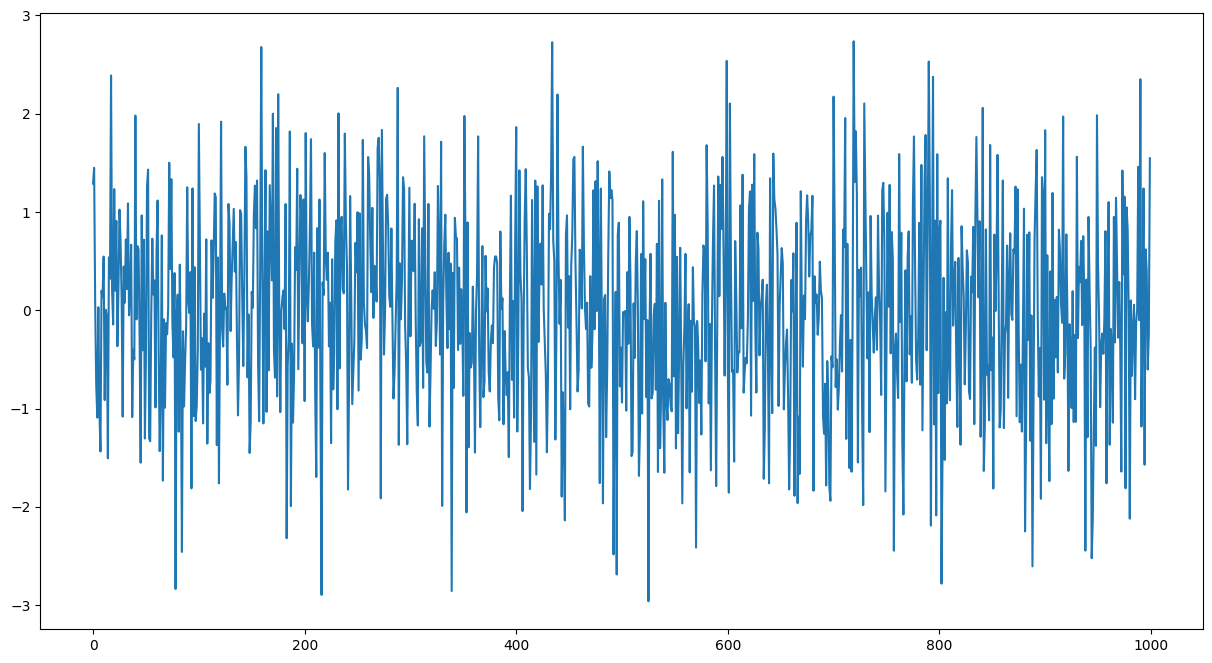

In [ ]:
# seed random number generator
seed(1)
# create white noise series
series = [gauss(0.0, 1.0) for i in range(1000)]
series = Series(series)

# line plot
plt.figure(figsize=(15,8))
series.plot()
plt.show()

In [ ]:
# Next, we can calculate and print some summary statistics, including the mean and standard deviation of the series.

# summary stats
series.describe()

,0
count,1000.000000
mean,-0.013222
std,1.003685
min,-2.961214
25%,-0.684192
50%,-0.010934
75%,0.703915
max,2.737260


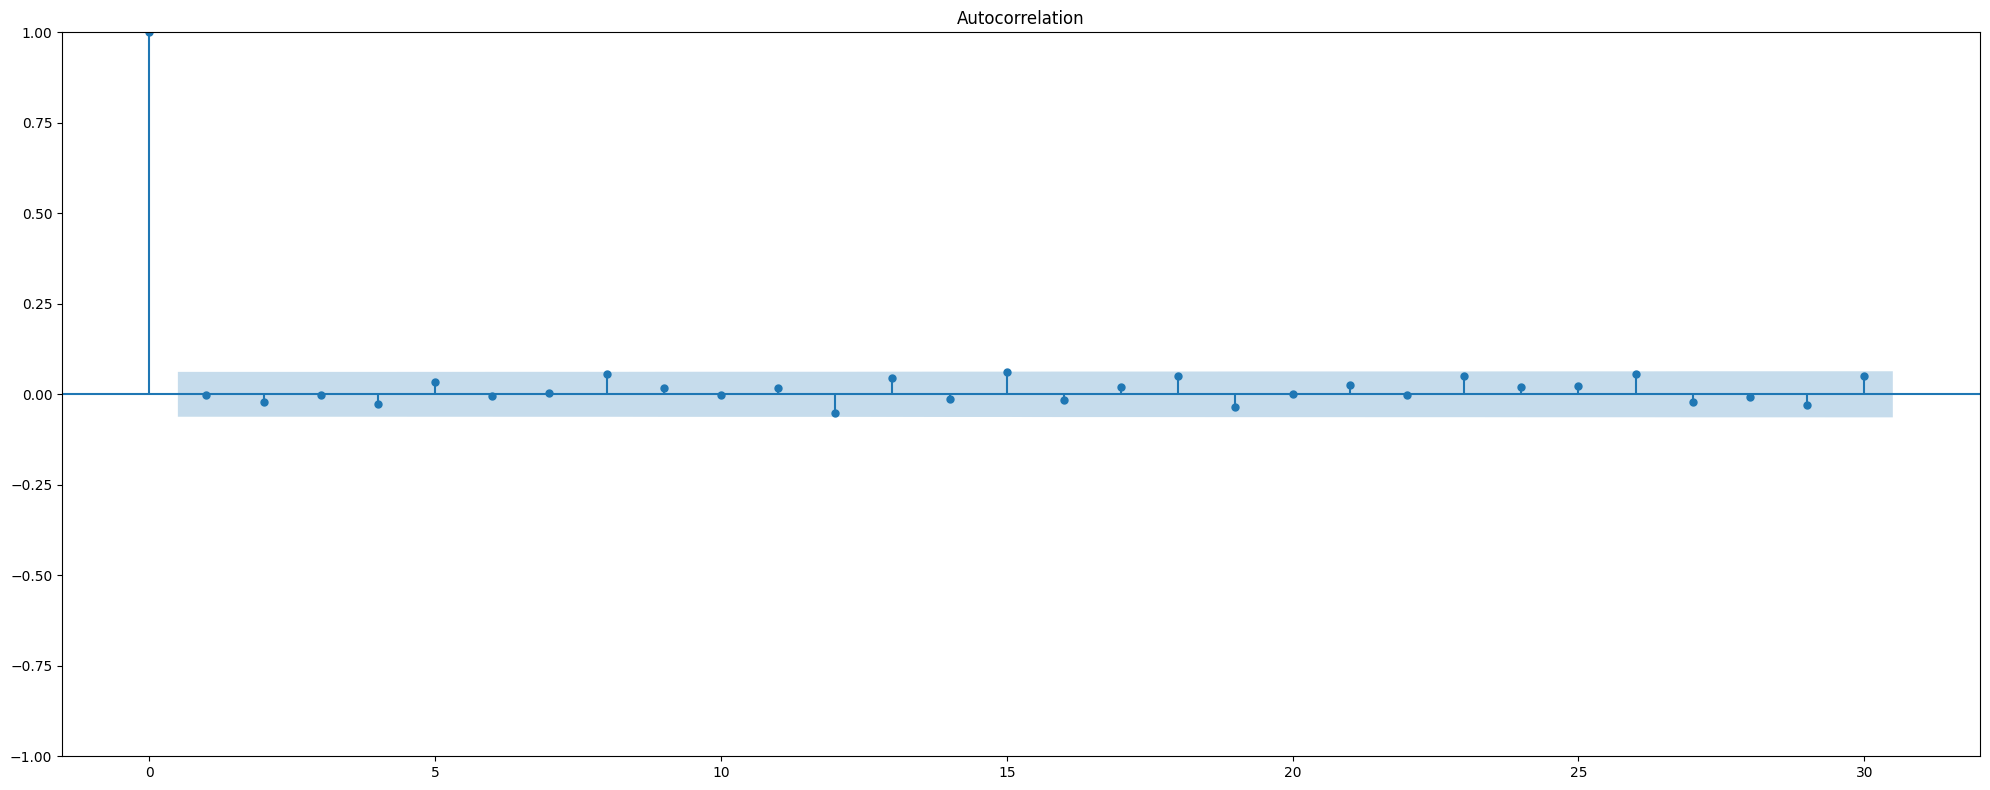

In [ ]:
# autocorrelation plot - see slides

fig = plot_acf(series, lags=30) #print only 30 lags
fig.set_size_inches((20,8))
# Tight layout to realign things
fig.tight_layout()
plt.show()

In summary:

1. White noise time series is defined by a zero mean, constant variance, and zero correlation.
2. If your time series is white noise, it cannot be predicted, and if your forecast residuals are not white noise, you may be able to improve your model.
3. Descriptive statistics and plots such as autocorrelation, line plots, and residual plots can be used on your time series to check if it is white noise.

This reference frame is used twice below: in the ACF interpretation, to establish that JPM is not white noise and therefore worth forecasting, and in the residual diagnostics, to test whether the fitted model has extracted all available signal.

## 1. Download stock data - single and multiple and get it into the right format

A way of getting the historical stock data is to use the pandas_datareader library.
It uses Yahoo’s Finance API to load in the data.

### First, download SINGLE stock using pandas_datareader

In [ ]:
# Define stock ticker and date range
stock_ticker = 'JPM'
stock_start_date = datetime.date(2013, 12, 29)
stock_end_date = datetime.date(2026, 9, 11)

# Fetch the stock price from Yahoo Finance using yfinance
stock_df = yf.download(stock_ticker, start=stock_start_date, end=stock_end_date)

/tmp/ipykernel_1884/959551367.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_df = yf.download(stock_ticker, start=stock_start_date, end=stock_end_date)
[*********************100%***********************]  1 of 1 completed


In [ ]:
stock_df

Price,Close,High,Low,Open,Volume
Ticker,JPM,JPM,JPM,JPM,JPM
Date,,,,,
2013-12-30,41.337528,41.565794,41.166328,41.473060,8815800
2013-12-31,41.715599,41.765532,41.408866,41.515867,11017400
2014-01-02,41.794563,42.002783,41.622246,41.866365,15627600
2014-01-03,42.117664,42.325884,41.794565,41.852006,14214100
2014-01-06,42.361774,42.699234,42.239716,42.476654,17550700
...,...,...,...,...,...
2026-09-01,354.950012,359.929993,354.119995,355.730011,5079000
2026-09-02,356.220001,361.470001,353.790009,357.549988,5341400


In [ ]:
stock_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3191 entries, 2013-12-30 to 2026-09-08
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (Close, JPM)   3191 non-null   float64
 1   (High, JPM)    3191 non-null   float64
 2   (Low, JPM)     3191 non-null   float64
 3   (Open, JPM)    3191 non-null   float64
 4   (Volume, JPM)  3191 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 149.6 KB


In [ ]:
stock_df.index

DatetimeIndex(['2013-12-30', '2013-12-31', '2014-01-02', '2014-01-03',
               '2014-01-06', '2014-01-07', '2014-01-08', '2014-01-09',
               '2014-01-10', '2014-01-13',
               ...
               '2026-08-25', '2026-08-26', '2026-08-27', '2026-08-28',
               '2026-08-31', '2026-09-01', '2026-09-02', '2026-09-03',
               '2026-09-04', '2026-09-08'],
              dtype='datetime64[ns]', name='Date', length=3191, freq=None)

In [ ]:
# delete 2013 values
stock_df=stock_df[(stock_df.index.year!=2013)]
stock_df

Price,Close,High,Low,Open,Volume
Ticker,JPM,JPM,JPM,JPM,JPM
Date,,,,,
2014-01-02,41.794563,42.002783,41.622246,41.866365,15627600
2014-01-03,42.117664,42.325884,41.794565,41.852006,14214100
2014-01-06,42.361774,42.699234,42.239716,42.476654,17550700
2014-01-07,41.873554,42.670531,41.722776,42.570012,17851200
2014-01-08,42.268444,42.297165,41.859186,42.031507,14687400
...,...,...,...,...,...
2026-09-01,354.950012,359.929993,354.119995,355.730011,5079000
2026-09-02,356.220001,361.470001,353.790009,357.549988,5341400


### Next, download multiple stock data using pandas_datareader

In [ ]:
# Downloading multiple stock using pandas_datareader

stock_ticker_multiple = ['JPM', 'SPY']

#start date and end date are same as before

In [ ]:
# Getting the data
stock_df_multiple = yf.download(stock_ticker_multiple,start=stock_start_date,end=stock_end_date)

/tmp/ipykernel_1884/28484449.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_df_multiple = yf.download(stock_ticker_multiple,start=stock_start_date,end=stock_end_date)
[*********************100%***********************]  2 of 2 completed


In [ ]:
stock_df_multiple

Price            Close                    High                     Low  \
Ticker             JPM         SPY         JPM         SPY         JPM   
Date                                                                     
2013-12-30   41.337524  148.927612   41.565790  149.089646   41.166324   
2013-12-31   41.715584  149.632507   41.765517  149.632507   41.408851   
2014-01-02   41.794575  148.198456   42.002794  149.130172   41.622257   
2014-01-03   42.117661  148.174179   42.325880  148.749414   41.794562   
2014-01-06   42.361786  147.744797   42.699245  148.717013   42.239728   
...                ...         ...         ...         ...         ...   
2026-09-01  354.950012  761.780029  359.929993  764.669983  354.119995   
2026-09-02  356.220001  765.159973  361.470001  766.429993  353.790009   
2026-09-03  362.059998  773.169983  362.850006  774.030029  356.390015   
2026-09-04  358.640015  770.190002  362.859985  772.869995  355.200012   
2026-09-08  353.510010  765.960022  358.323303  769.700012  353.239990   

Price                         Open                Volume             
Ticker             SPY         JPM         SPY       JPM        SPY  
Date                                                                 
2013-12-30  148.733164   41.473056  148.968112   8815800   56857000  
2013-12-31  149.016761   41.515852  149.130198  11017400   86119900  
2014-01-02  147.841974   41.866376  149.057247  15627600  119636900  
2014-01-03  147.963536   41.852003  148.449638  14214100   81390600  
2014-01-06  147.517947   42.476665  148.660306  17550700  108028200  
...                ...         ...         ...       ...        ...  
2026-09-01  759.479980  355.730011  762.010010   5079000   41126300  
2026-09-02  761.729980  357.549988  762.450012   5341400   29566200  
2026-09-03  767.450012  358.679993  767.900024   5414200   43531600  
2026-09-04  769.000000  361.000000  772.010010   4873500   34015600  
2026-09-08  765.150024  357.100006  769.070007   5627535   43496831  

[3191 rows x 10 columns]

In [ ]:
#check column names
stock_df_multiple.columns

MultiIndex([( 'Close', 'JPM'),
            ( 'Close', 'SPY'),
            (  'High', 'JPM'),
            (  'High', 'SPY'),
            (   'Low', 'JPM'),
            (   'Low', 'SPY'),
            (  'Open', 'JPM'),
            (  'Open', 'SPY'),
            ('Volume', 'JPM'),
            ('Volume', 'SPY')],
           names=['Price', 'Ticker'])

In [ ]:
#handle multiple indexes
stock_df_multiple.columns = stock_df_multiple.columns.map('_'.join).str.replace(' ','_')

In [ ]:
#select only the closing price columns for both stock tickers
stock_df_multiple = stock_df_multiple[['Close_JPM', 'Close_SPY']]

In [ ]:
stock_df_multiple

,Close_JPM,Close_SPY
Date,,
2013-12-30,41.337524,148.927612
2013-12-31,41.715584,149.632507
2014-01-02,41.794575,148.198456
2014-01-03,42.117661,148.174179
2014-01-06,42.361786,147.744797
...,...,...
2026-09-01,354.950012,761.780029
2026-09-02,356.220001,765.159973
2026-09-03,362.059998,773.169983


### Download the three US economic indicators from FRED

Source: Federal Reserve Bank of St. Louis, https://fred.stlouisfed.org/

In [ ]:
factor_df = pdr.DataReader(['UNRATE','CPIAUCSL','FEDFUNDS'], 'fred',
                           stock_start_date, stock_end_date)
factor_df.tail()

,UNRATE,CPIAUCSL,FEDFUNDS
DATE,,,
2026-04-01,4.3,332.407,3.64
2026-05-01,4.3,333.979,3.63
2026-06-01,4.2,332.568,3.63
2026-07-01,4.1,332.813,3.63
2026-08-01,4.1,NaN,3.63


In [ ]:
print("Missing values in economic indicators:")
print(factor_df.isnull().sum())

Missing values in economic indicators:
UNRATE      1
CPIAUCSL    2
FEDFUNDS    0
dtype: int64


The trailing NaN values are not a download error. They reflect publication lag: FEDFUNDS is never missing because the policy rate is set administratively rather than surveyed, UNRATE is released in the first week of the following month, and CPIAUCSL lags furthest behind. These rows are removed when the datasets are merged below.

## 2. Exploratory Data Analysis (EDA)


In [ ]:
#delete year 2013
stock_df_multiple.index = pd.to_datetime(stock_df_multiple.index)
stock_df_multiple = stock_df_multiple[(stock_df_multiple.index.year!=2013)]
stock_df_multiple

,Close_JPM,Close_SPY
Date,,
2014-01-02,41.794575,148.198456
2014-01-03,42.117661,148.174179
2014-01-06,42.361786,147.744797
2014-01-07,41.873547,148.652161
2014-01-08,42.268444,148.684586
...,...,...
2026-09-01,354.950012,761.780029
2026-09-02,356.220001,765.159973
2026-09-03,362.059998,773.169983


In [ ]:
# 1. Descriptive Statistics
stock_df_multiple.describe()

,Close_JPM,Close_SPY
count,3189.000000,3189.000000
mean,122.916641,342.440169
std,79.326862,165.263683
min,38.517639,141.109375
25%,67.421043,202.630753
50%,95.060326,291.975769
75%,142.666046,428.900146
max,365.179993,777.880005


<Axes: >

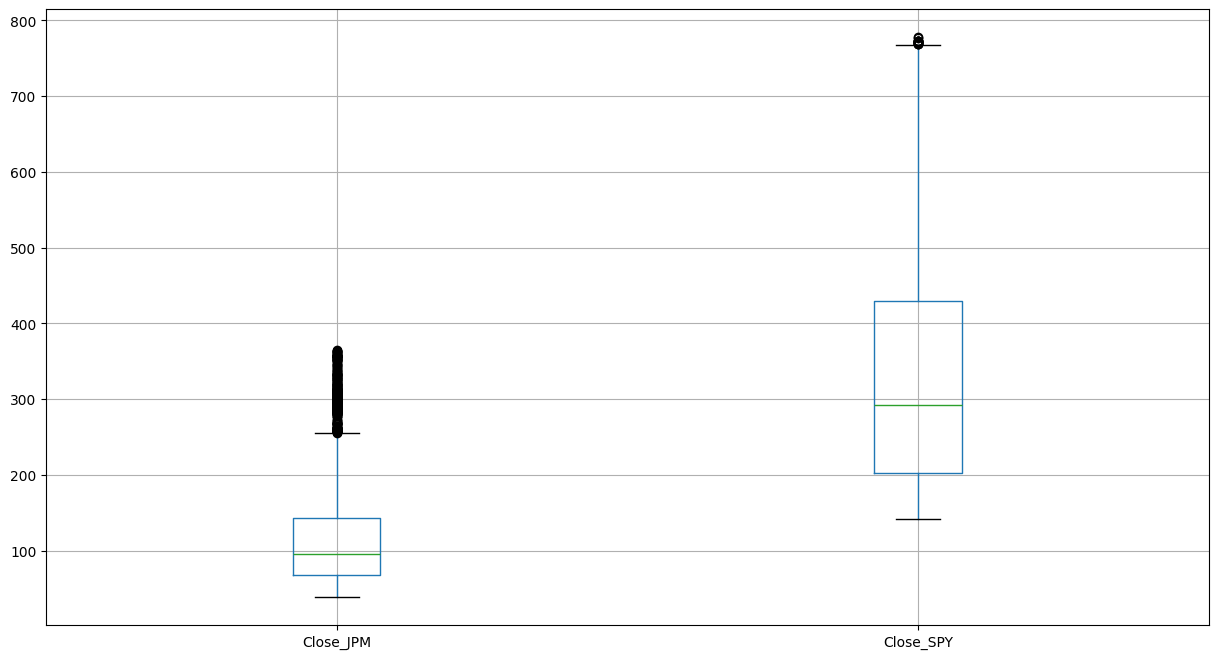

In [ ]:
plt.figure(figsize=(15,8))
stock_df_multiple.boxplot()

In [ ]:
# 2. Check for missing values
stock_df_multiple.isnull().sum()

,0
Close_JPM,0
Close_SPY,0


In [ ]:
# 3. Find the indexes that are missing
pd.date_range(start = '2014-01-01', end = stock_end_date).difference(stock_df_multiple.index)

DatetimeIndex(['2014-01-01', '2014-01-04', '2014-01-05', '2014-01-11',
               '2014-01-12', '2014-01-18', '2014-01-19', '2014-01-20',
               '2014-01-25', '2014-01-26',
               ...
               '2026-08-22', '2026-08-23', '2026-08-29', '2026-08-30',
               '2026-09-05', '2026-09-06', '2026-09-07', '2026-09-09',
               '2026-09-10', '2026-09-11'],
              dtype='datetime64[ns]', length=1448, freq=None)

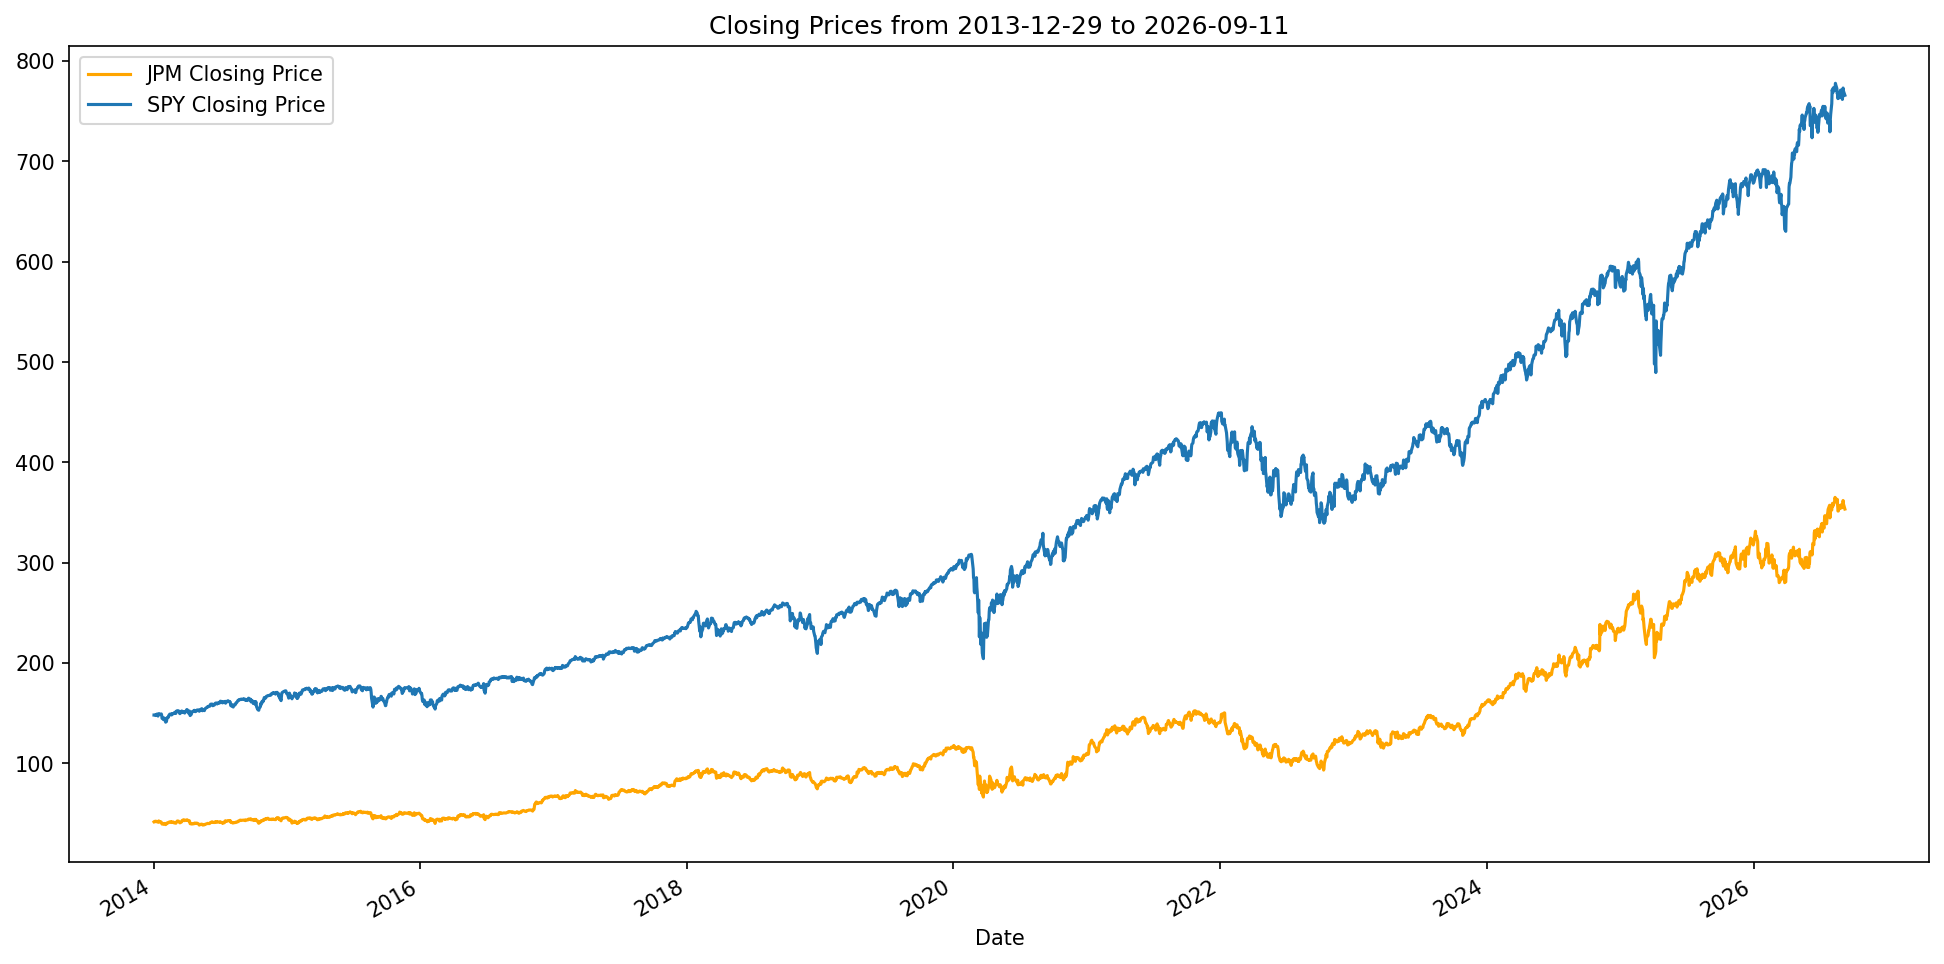

In [ ]:
# Visualizing The Close Price of the stocks

# to set the plot size
plt.figure(figsize=(16, 8), dpi=150) #dpi = resolution. default 100.

# using plot method to plot close prices.
# in plot method we set the label and color of the curve.
stock_df_multiple['Close_JPM'].plot(label='JPM Closing Price', color='orange')
stock_df_multiple['Close_SPY'].plot(label='SPY Closing Price')

# adding title to the plot
plt.title('Closing Prices from {} to {}'.format(stock_start_date, stock_end_date))

# adding Label to the x-axis
plt.xlabel('Date')

# adding legend to the curve
plt.legend()


In [ ]:
# 4. Let's complete the broken time series indexes and interpolate (impute missing values) the data

# SEE SLIDES

**Impute Missing Values**

Some time series models work with complete data, and therefore they require the missing data to be replaced with meaningful values before actual analysis. At a high level, missing values in time series are handled in two ways, either dropping them or replacing them. However, dropping missing values can be an inappropriate solution due to the time order of the data and the correlation between observations in adjacent periods.

Estimating a reasonable value such that the components of the series are not distorted is an excellent approach to dealing with missing values in time series. Imputation replaces missing values with values estimated from the same data or observed from the environment with the same conditions underlying the missing data.

Different ways to impute the missing values are as follows.
1. Mean or Median imputation
2. Last Observation Carried Forward (LOCF) or forward fill - the missing value is imputed using the values before it in the time series
3. Next Observation Carried Backward (NOCB) or back fill- the missing values are imputed using an immediate value ahead of them
4. Linear interpolation - estimates unknown values by assuming linear relation within a range of data points
5. Spline interpolation - estimates values that minimize overall curvature, thus obtaining a smooth surface passing through the input points


In [ ]:
# first, fill the misssing values with 'NaN'. Reindexing.
stock_df_multiple_NaN = stock_df_multiple.reindex(pd.date_range('2014-01-01', stock_end_date), fill_value= np.nan)
stock_df_multiple_NaN

,Close_JPM,Close_SPY
2014-01-01,NaN,NaN
2014-01-02,41.794575,148.198456
2014-01-03,42.117661,148.174179
2014-01-04,NaN,NaN
2014-01-05,NaN,NaN
...,...,...
2026-09-07,NaN,NaN
2026-09-08,353.510010,765.960022
2026-09-09,NaN,NaN
2026-09-10,NaN,NaN


In [ ]:
# next, let's use ALL the different imputation techniques on JPM and just the spline on SPY

stock_df_multiple_imputed = stock_df_multiple_NaN.copy()
stock_df_multiple_imputed['JPM_Spline']= stock_df_multiple_imputed['Close_JPM'].interpolate(method='spline', order=1, limit=10, limit_direction='both')
stock_df_multiple_imputed['JPM_Linear']= stock_df_multiple_imputed['Close_JPM'].interpolate(method='linear', order=1, limit=10, limit_direction='both')
stock_df_multiple_imputed['JPM_ffill']= stock_df_multiple_imputed['Close_JPM'].ffill()
stock_df_multiple_imputed['JPM_bfill']= stock_df_multiple_imputed['Close_JPM'].bfill()
stock_df_multiple_imputed['JPM_Mean']= stock_df_multiple_imputed['Close_JPM'].fillna(stock_df_multiple_imputed['Close_JPM'].mean())
stock_df_multiple_imputed['JPM_Median']= stock_df_multiple_imputed['Close_JPM'].fillna(stock_df_multiple_imputed['Close_JPM'].median())
stock_df_multiple_imputed['SPY_Spline']= stock_df_multiple_imputed['Close_SPY'].interpolate(method='spline', order=1, limit=10, limit_direction='both')

stock_df_multiple_imputed.round(2)


,Close_JPM,Close_SPY,JPM_Spline,JPM_Linear,JPM_ffill,JPM_bfill,JPM_Mean,JPM_Median,SPY_Spline
2014-01-01,NaN,NaN,42.35,41.79,NaN,41.79,122.92,95.06,148.22
2014-01-02,41.79,148.20,41.79,41.79,41.79,41.79,41.79,41.79,148.20
2014-01-03,42.12,148.17,42.12,42.12,42.12,42.12,42.12,42.12,148.17
2014-01-04,NaN,NaN,42.17,42.20,42.12,42.36,122.92,95.06,148.34
2014-01-05,NaN,NaN,42.11,42.28,42.12,42.36,122.92,95.06,148.37
...,...,...,...,...,...,...,...,...,...
2026-09-07,NaN,NaN,354.85,354.79,358.64,353.51,122.92,95.06,767.02
2026-09-08,353.51,765.96,353.51,353.51,353.51,353.51,353.51,353.51,765.96
2026-09-09,NaN,NaN,352.15,353.51,353.51,NaN,122.92,95.06,764.89
2026-09-10,NaN,NaN,350.81,353.51,353.51,NaN,122.92,95.06,763.83


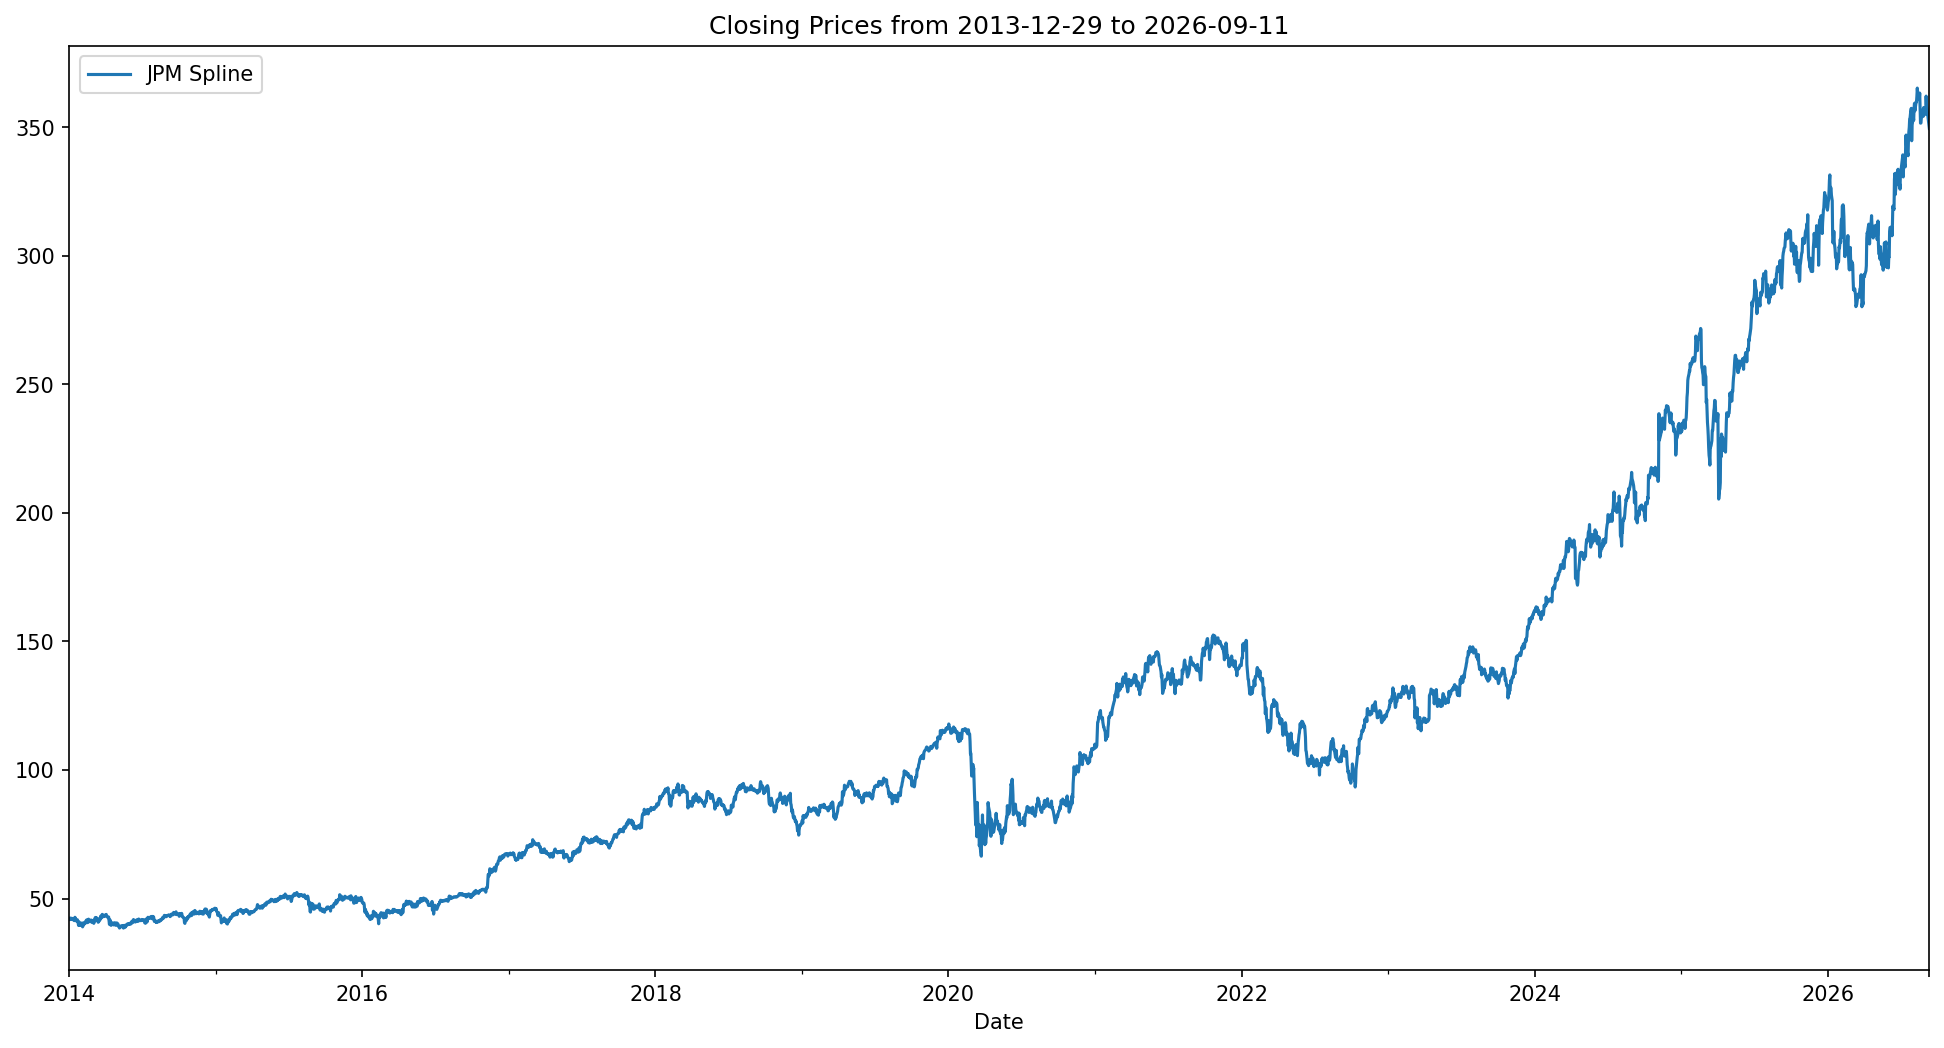

In [ ]:
#Plot

# to set the plot size
plt.figure(figsize=(16, 8), dpi=150)

# using plot method to plot close prices.
# in plot method we set the label and color of the curve.
#stock_df_multiple_imputed['JPM_Median'].plot(label='JPM Median', color='orange')
#stock_df_multiple_imputed['JPM_Linear'].plot(label='JPM Linear')
#stock_df_multiple_imputed['JPM_bfill'].plot(label='JPM Backfill')
stock_df_multiple_imputed['JPM_Spline'].plot(label='JPM Spline')


# adding title to the plot
plt.title('Closing Prices from {} to {}'.format(stock_start_date, stock_end_date))

# adding Label to the x-axis
plt.xlabel('Date')

# adding legend to the curve
plt.legend()


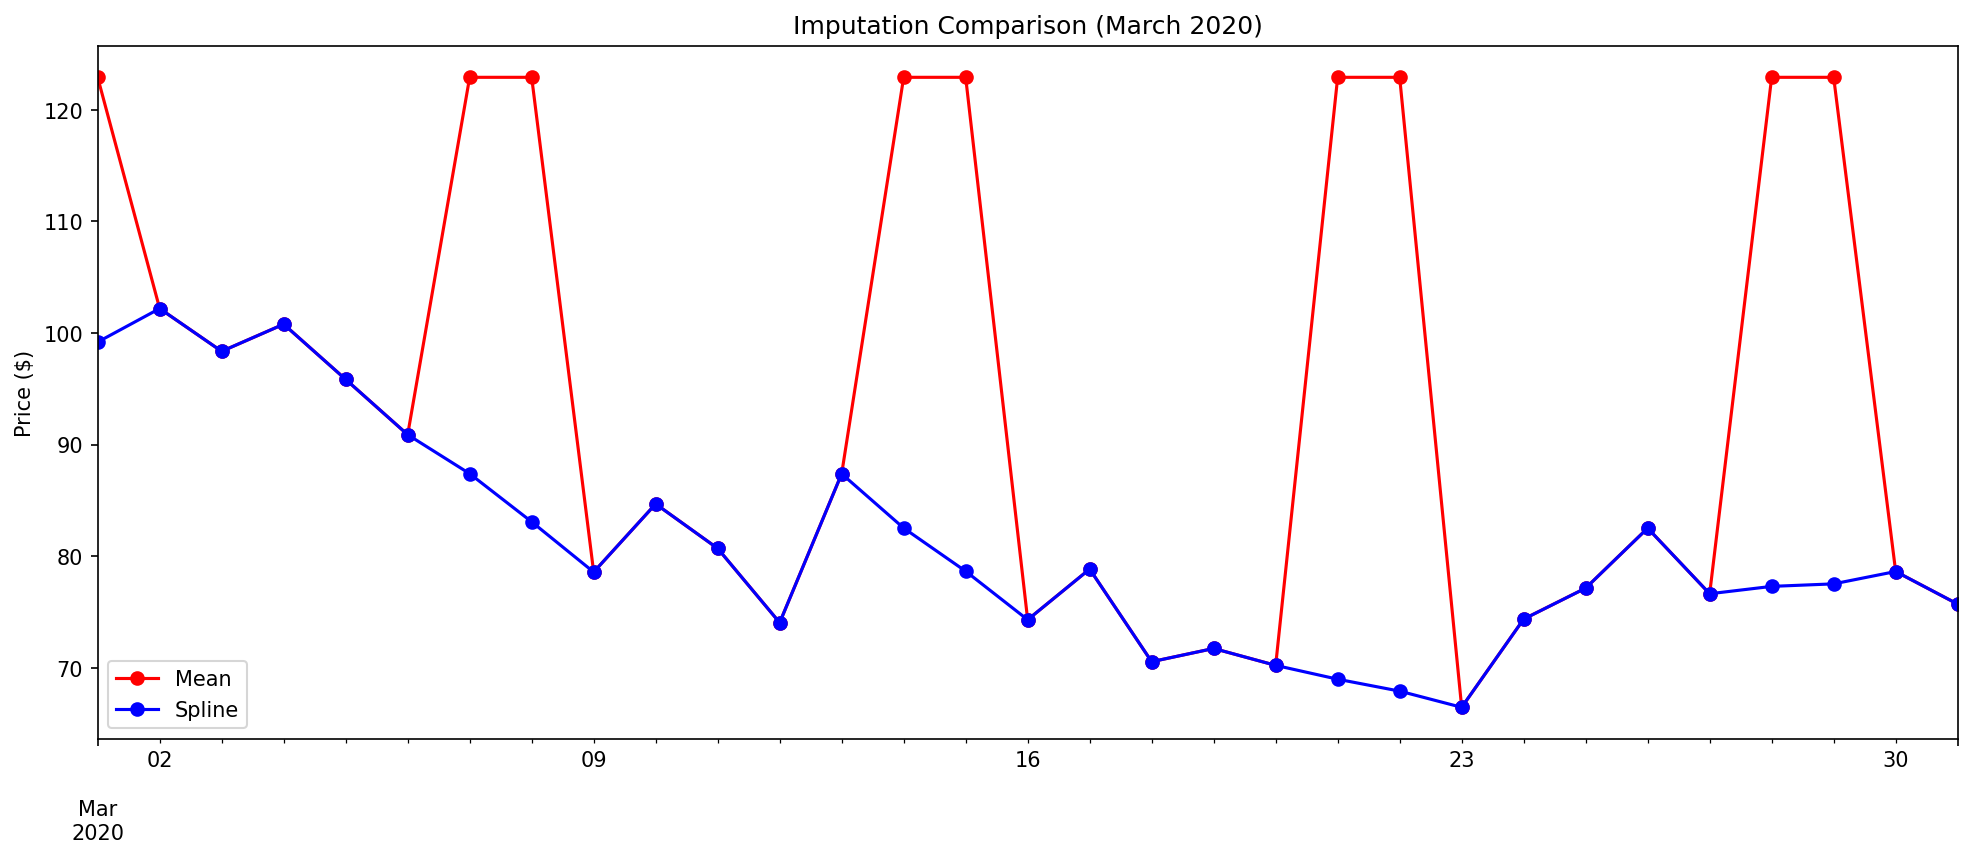

In [ ]:
# March 2020 detail - what value lands on each non-trading day
zoom = stock_df_multiple_imputed.loc['2020-03-01':'2020-03-31']

plt.figure(figsize=(16, 6), dpi=150)
zoom['JPM_Mean'].plot(label='Mean', color='red', marker='o')
zoom['JPM_Spline'].plot(label='Spline', color='blue', marker='o')
plt.title('Imputation Comparison (March 2020)')
plt.ylabel('Price ($)')
plt.legend()
plt.show()

**Which imputation technique does not make sense, and why?**

Mean and median imputation are inappropriate here. Both replace every missing value with a single constant calculated from the entire 2014-2026 window (approximately \$123 for JPM). Since JPM traded near \$42 in 2014 and reached a high of \$365 in 2026, this constant overstates early prices by roughly 3x and understates recent prices by a similar margin.

The March 2020 detail above makes this concrete: while JPM fell from \$102 to \$68 during the COVID selloff, mean imputation inserted \$123 on every non-trading day, spiking above the actual price level on all four weekends of that month.

The underlying problem is that mean and median discard the time ordering of the series. Spline, linear, forward fill, and backward fill each draw on neighbouring observations, so the imputed value reflects the price level at that point in time.

Among the four viable methods, interpolation is preferred over fill methods. Forward fill creates artificial flat steps across every weekend, and backward fill inserts Monday's price into Saturday, which introduces look-ahead bias into a forecasting exercise. Linear and spline interpolation avoid both issues; with `order=1` they produce nearly identical values, and spline is used here for consistency with the downstream analysis.

Brief overview of Outlier Detection techniques can be found here: https://cnvrg.io/anomaly-detection-python/

1. Distribution-based techniques – Minimum Covariance Determinant, Elliptic Envelope
2. Depth-based technique – Isolation Forest
3. Clustering-based technique – Local Outlier Factor
4. Density-based technique – DBSCAN
5. Unified library for Outlier Detection – PyOD
6. Statistical techniques – Interquartile range
7. Visualization techniques – Box-plot

<Axes: xlabel='None', ylabel='JPM_Spline'>

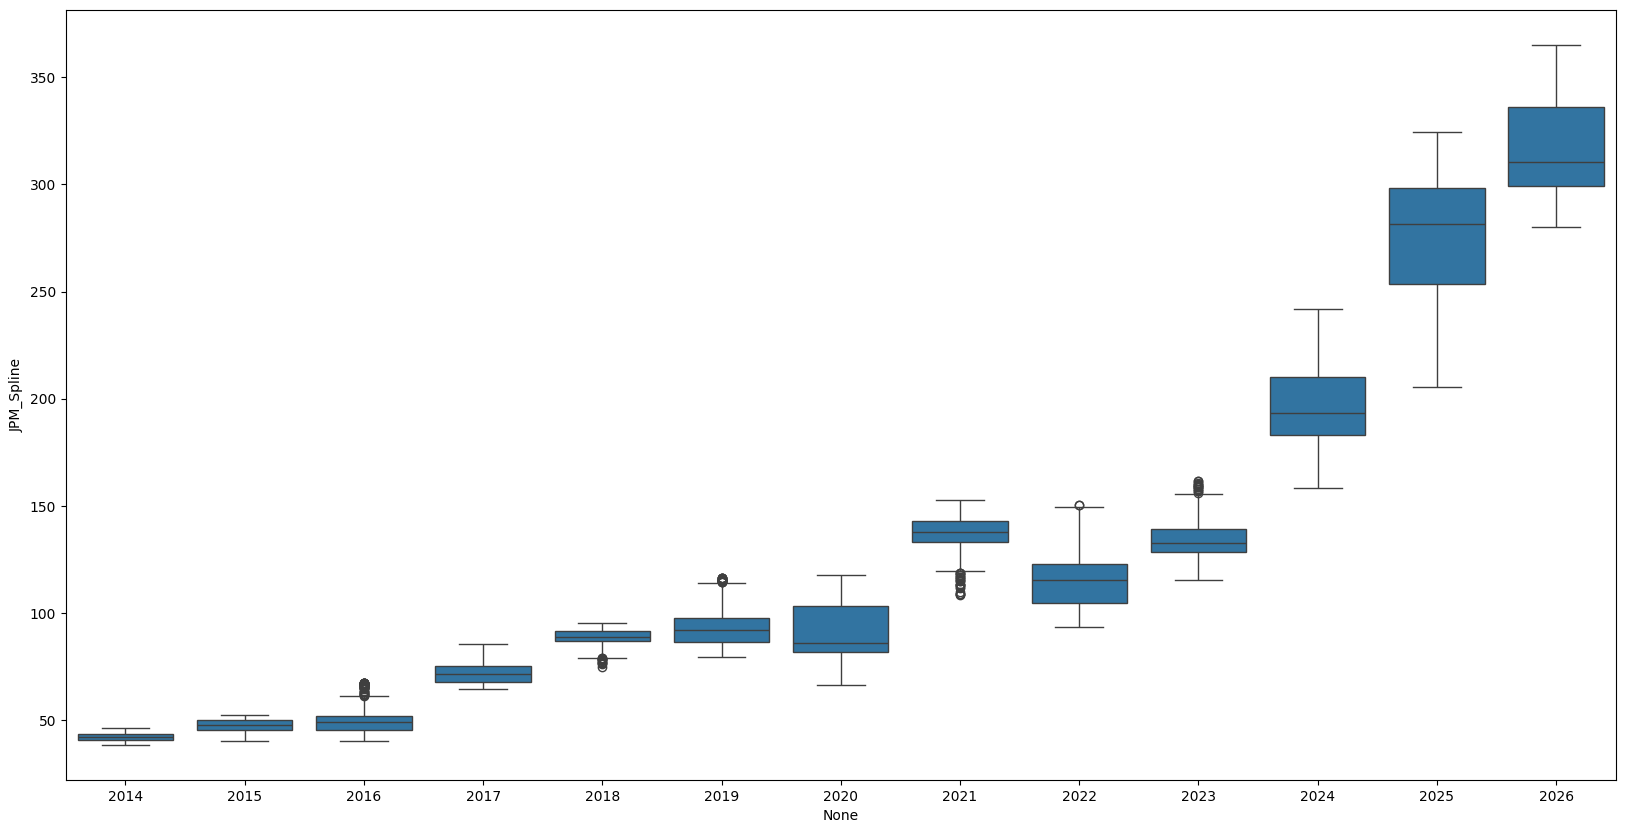

In [ ]:
# price variation for each year

fig, ax = plt.subplots(figsize=(20,10))
sns.boxplot(x = stock_df_multiple_imputed.index.year,
                y = stock_df_multiple_imputed['JPM_Spline'],
                ax = ax)

**Why is outlier detection important?**

Outliers distort model fitting. Exponential smoothing estimates the level from a
weighted average of past observations, so an extreme value pulls the estimated
level away from the true state of the series and propagates into subsequent
forecasts.

For this series the more useful question is whether apparent outliers are
genuine anomalies or artifacts of the visualization. A boxplot of the full price
history flags several hundred recent observations as outliers, but those prices
are entirely normal for their point in time. Splitting by year resolves this:
within each year, recent prices are no longer extreme.

The boxes rise in a staircase from a 2014 median of roughly $[2014 median] to a 2026 median of \$[2026 median], confirming a strong upward trend. Two years interrupt the pattern, 2020 and
2022. Because these setbacks occur at irregular intervals they are cyclical
rather than seasonal and cannot be used for forecasting.

**Log Scale Plot:** This will show you if the "volatility" (the height of the boxes) is actually increasing, or if it just looks like it's increasing because the stock price is higher. If the boxes stay roughly the same height on a log scale, the stock's relative risk hasn't changed.

/tmp/ipykernel_1884/960560939.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=stock_df_multiple_imputed.index.year,


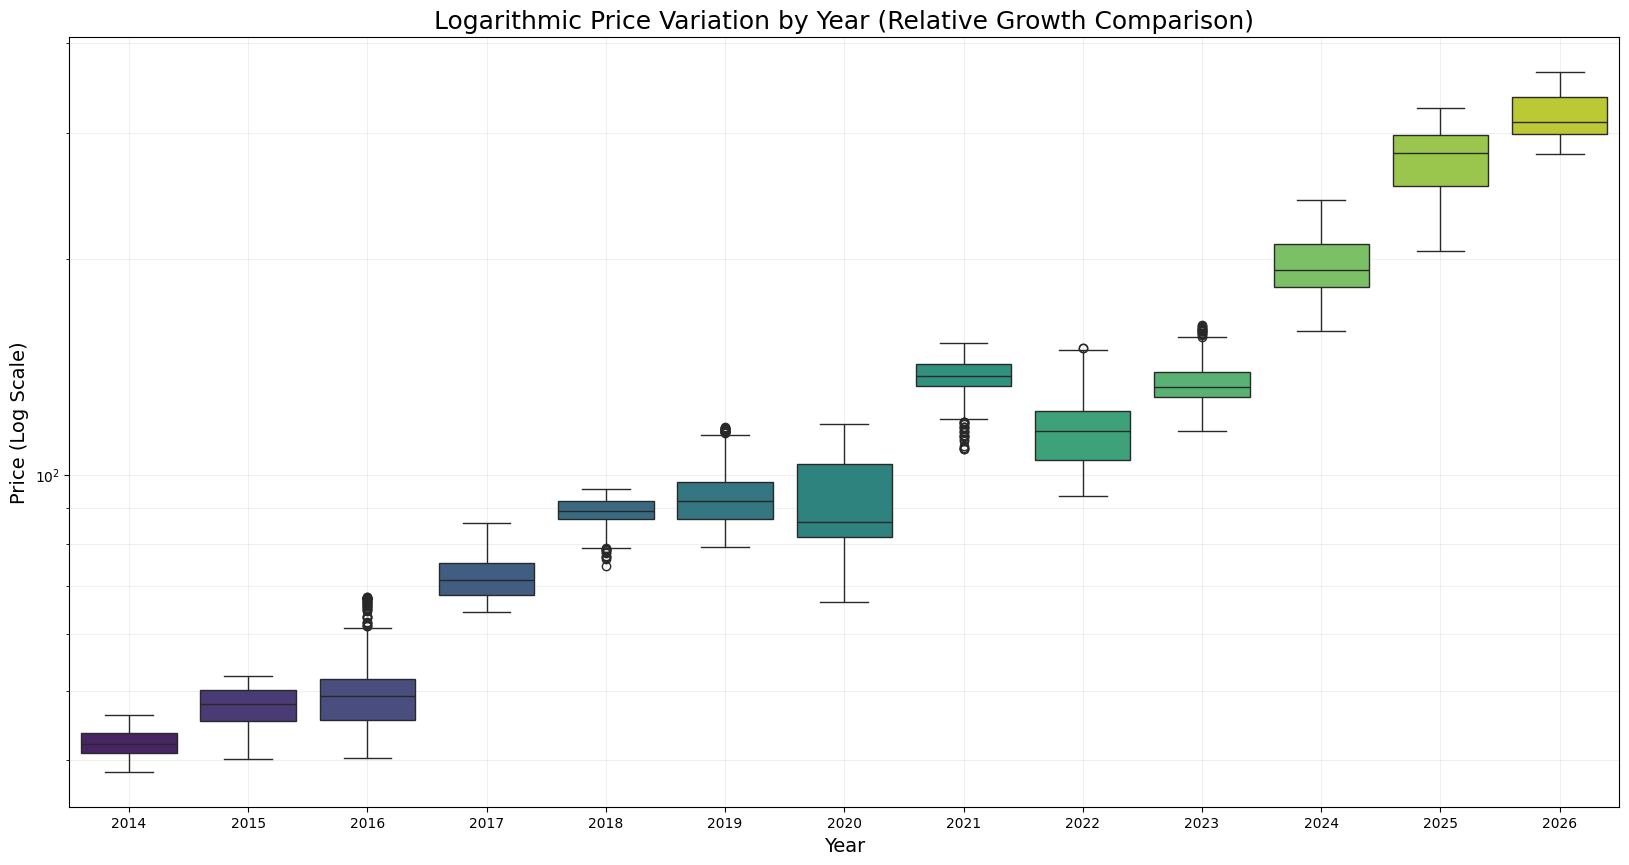

In [ ]:
# Create the plot
fig, ax = plt.subplots(figsize=(20, 10))

# We use the same boxplot logic but add a log scale to the Y-axis
sns.boxplot(x=stock_df_multiple_imputed.index.year,
            y=stock_df_multiple_imputed['JPM_Spline'],
            palette="viridis", # Adds a nice color gradient over the years
            ax=ax)

# SET TO LOG SCALE
ax.set_yscale('log')

# Update labels to reflect the change
ax.set_title('Logarithmic Price Variation by Year (Relative Growth Comparison)', fontsize=18)
ax.set_ylabel('Price (Log Scale)', fontsize=14)
ax.set_xlabel('Year', fontsize=14)
ax.grid(True, which="both", ls="-", alpha=0.2) # Adding gridlines helps read log scales

plt.show()

**The Insight:**

On a linear scale the boxes grow taller over time, but that is expected: a 2% move on a \$350 stock is worth seven times a 2% move on a \$50 stock. The log scale removes the price level so the boxes can be compared as percentage dispersion.

Reading the plot, the boxes are not uniform. 2014 through 2016 are visibly taller than 2023 onward, meaning percentage swings were larger when the price level was lower. Relative volatility has compressed rather than stayed constant.

The point that matters for forecasting is the direction. Rising log boxes would signal a stock becoming genuinely more unstable; here they narrow, so the growing boxes on the linear scale are a price-level artifact and not a rising-risk signal.




**Year-over-Year (YoY) Growth %:**

Instead of plotting the raw price, plot the percentage change from the first day of each year. This levels the playing field so you can see which year was actually the strongest performer relative to its start.

/tmp/ipykernel_1884/1839699440.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Year', y='Growth_Pct', data=df_yoy, palette="magma")


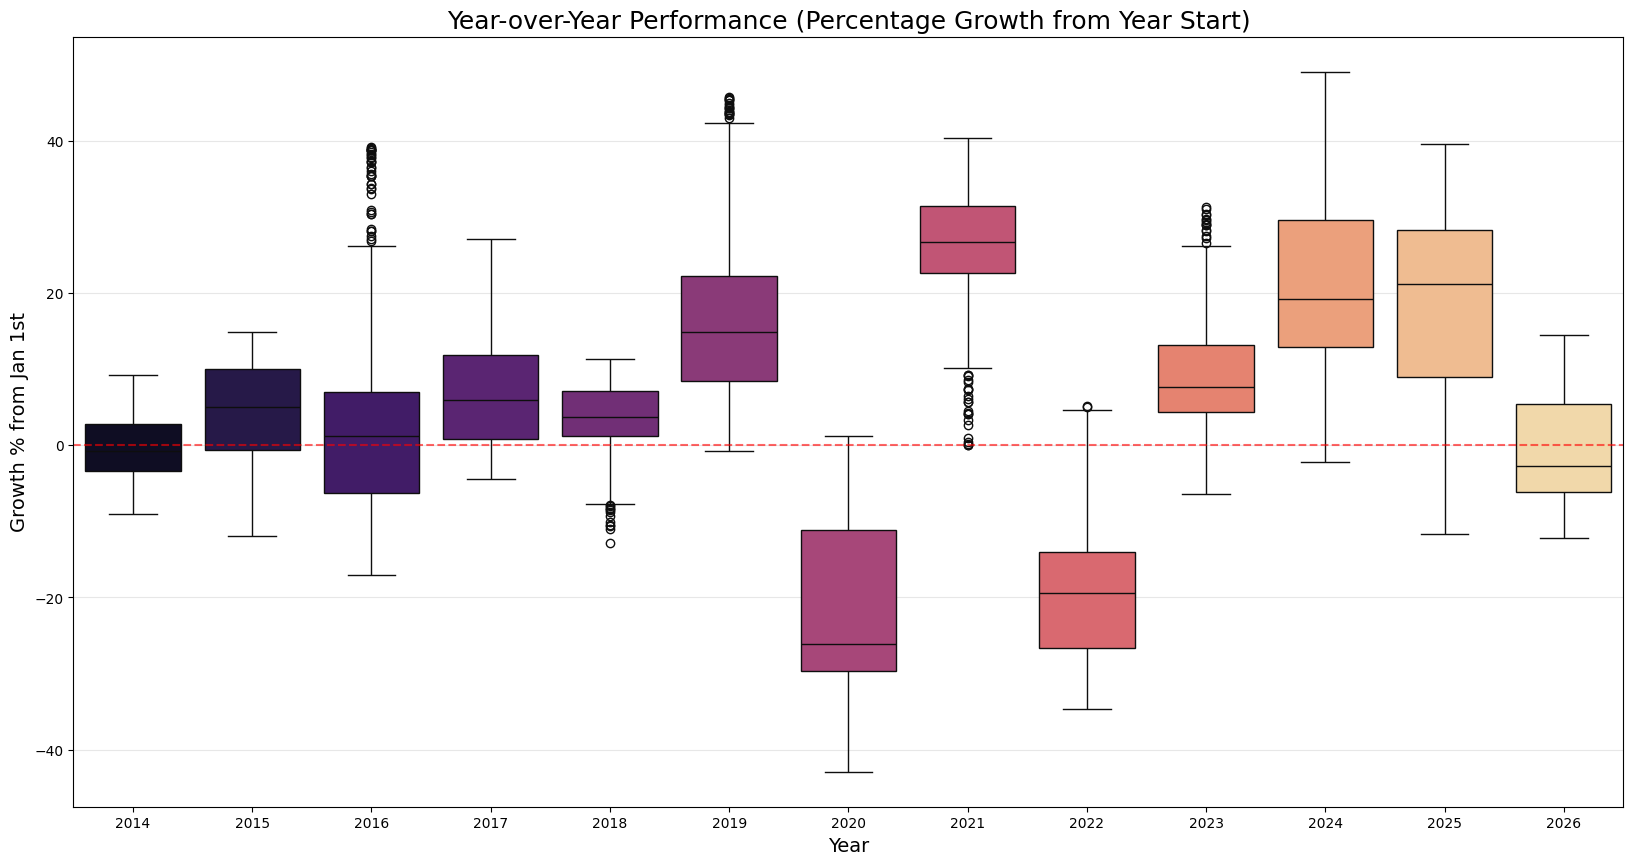

In [ ]:
# 1. Calculate the YoY Growth %
# We group by year and divide every price by the first price recorded in that specific year
yoy_growth = stock_df_multiple_imputed.groupby(stock_df_multiple_imputed.index.year)['JPM_Spline'].transform(
    lambda x: (x / x.iloc[0] - 1) * 100
)

# 2. Create a temporary DataFrame for plotting
df_yoy = pd.DataFrame({
    'Year': stock_df_multiple_imputed.index.year,
    'Growth_Pct': yoy_growth
})

# 3. Plot
plt.figure(figsize=(20, 10))
sns.boxplot(x='Year', y='Growth_Pct', data=df_yoy, palette="magma")

# Add a horizontal line at 0 to see which months/years were in the red
plt.axhline(0, color='red', linestyle='--', alpha=0.6)

plt.title('Year-over-Year Performance (Percentage Growth from Year Start)', fontsize=18)
plt.ylabel('Growth % from Jan 1st', fontsize=14)
plt.xlabel('Year', fontsize=14)
plt.grid(axis='y', alpha=0.3)

plt.show()

**Insights: YoY Performance**

1. 2022 (Bear): The only year where the entire distribution sits below the 0% baseline, indicating a sustained downward trend with sharp "drawdown" outliers.

2. 2023 (Recovery): A transitional "climb-back" phase where the stock stabilized and rebounded to a positive median growth of 15%–20%.

3. 2024 (Bull): The strongest regime; even the yearly "lows" remain above the January 1st price, signaling high-conviction buying and aggressive momentum.

4. 2026 (Consolidation): The box straddles the 0% line with a median close to flat. After two strong years the stock paused rather than continued, which is the pattern that penalises trend-extrapolating models in the forecasting section below.

<Axes: xlabel='None', ylabel='JPM_Spline'>

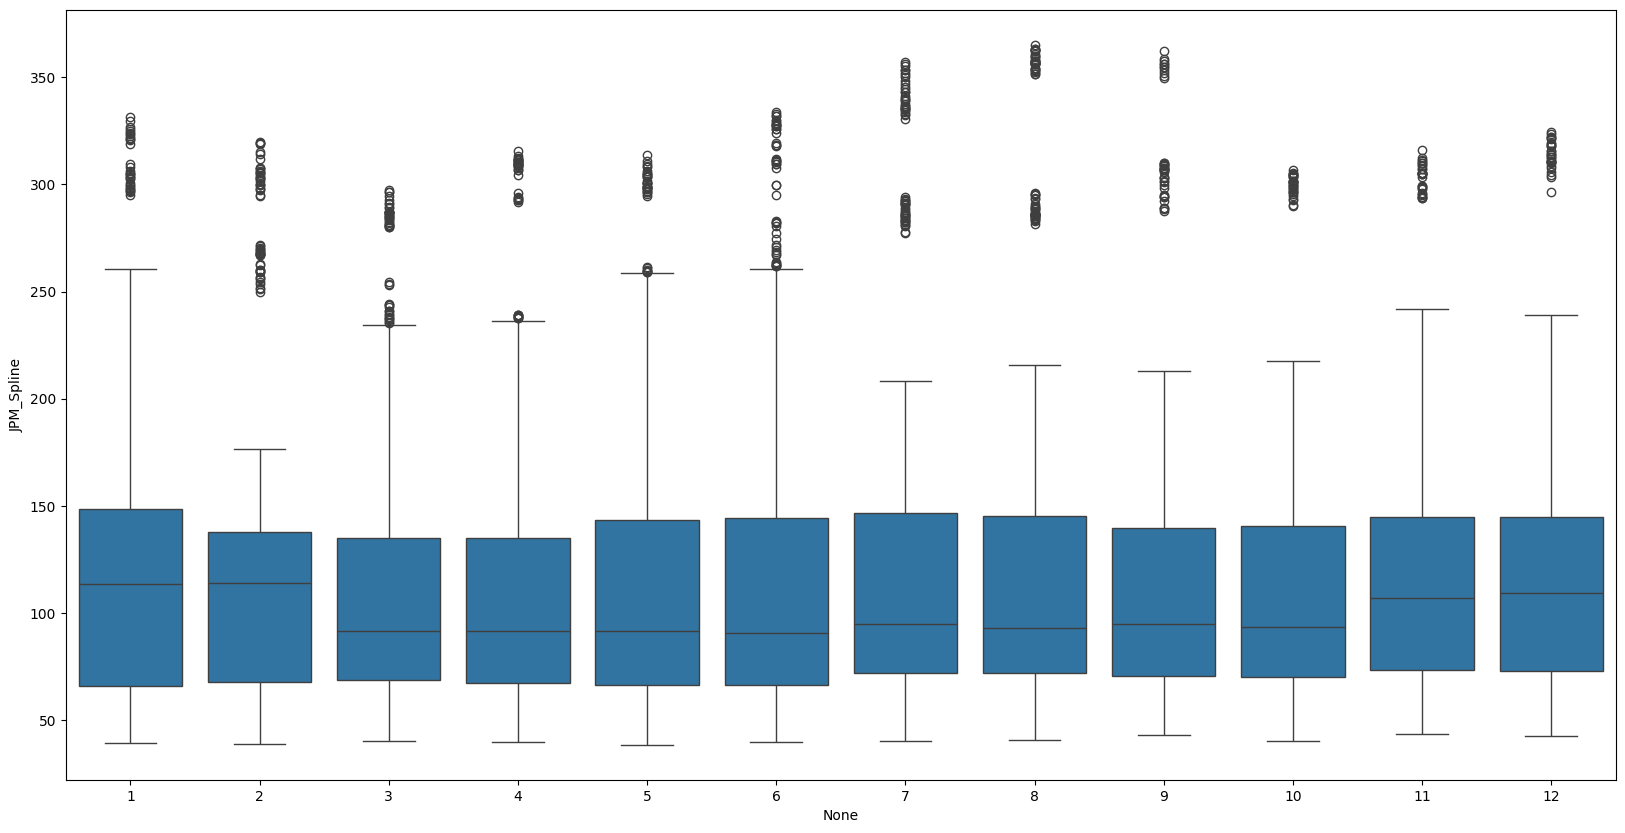

In [ ]:
# price variation for each month

fig, ax = plt.subplots(figsize=(20,10))
sns.boxplot(x = stock_df_multiple_imputed.index.month,
                y = stock_df_multiple_imputed['JPM_Spline'],
                ax = ax)

**Monthly Analysis**

1. When plotted as absolute prices, the monthly distributions appear uniform with high variance. This is a result of long-term price appreciation (trend) masking seasonal effects.

2. **Key Insight:** To isolate true seasonality (e.g., "Is March usually better than August?"), we must analyze percentage returns rather than price levels.


/tmp/ipykernel_1884/2176142911.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = stock_df_multiple_imputed.index.month,


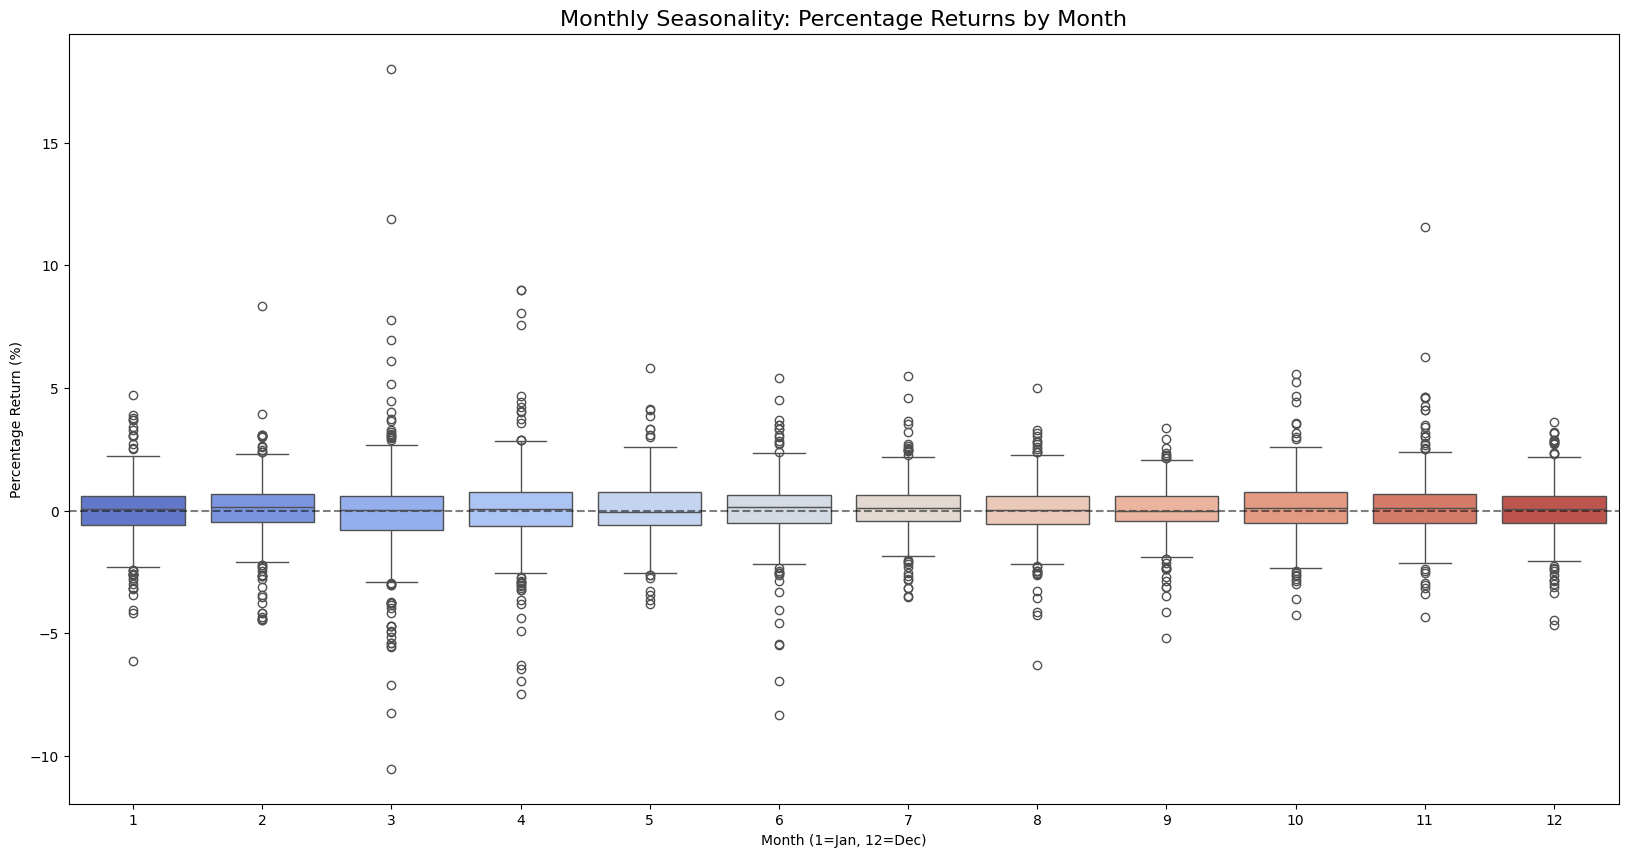

In [ ]:
# 1. Calculate Monthly Return %
stock_df_multiple_imputed['Monthly_Return'] = stock_df_multiple_imputed['JPM_Spline'].pct_change() * 100

# 2. Plotting Returns instead of Price
fig, ax = plt.subplots(figsize=(20,10))
sns.boxplot(x = stock_df_multiple_imputed.index.month,
            y = stock_df_multiple_imputed['Monthly_Return'],
            palette="coolwarm", # Red for potentially volatile, blue for cool
            ax = ax)

plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title('Monthly Seasonality: Percentage Returns by Month', fontsize=16)
plt.xlabel('Month (1=Jan, 12=Dec)')
plt.ylabel('Percentage Return (%)')
plt.show()

**Seasonality assessment**

Once returns replace price levels, the twelve monthly distributions are
effectively identical: every median sits at approximately 0% and the
interquartile ranges are comparable across all months. No month shows a
systematic tendency to rise or fall.

March displays a wider spread with outliers reaching +18% and -10.5%, but the
dispersion is symmetric around zero rather than directional. This reflects the
March 2020 selloff and recovery, a one-time event rather than a recurring
seasonal pattern.

**Implication for model selection.** JPM exhibits strong trend and no
seasonality. Triple ETS, which estimates a seasonal component, is expected to
overfit noise on this series. Double ETS, which models level and trend only, is
the anticipated best performer.

Resampling involves changing the frequency of your time series observations. Two types of
resampling are:
1. Upsampling: Where you increase the frequency of the samples, such as from minutes to seconds.
2. Downsampling: Where you decrease the frequency of the samples, such as from days to months.

In both cases, data must be invented. In the case of upsampling, care may be needed in
determining how the fine-grained observations are calculated using interpolation. In the case of
downsampling, care may be needed in selecting the summary statistics used to calculate the
new aggregated values.

There are perhaps two main reasons why you may be interested in resampling your time
series data:
1. Problem Framing: Resampling may be required if your data is not available at the same frequency that you want to make predictions.
2. Feature Engineering: Resampling can also be used to provide additional structure or insight into the learning problem for supervised learning models.

There is a lot of overlap between these two cases. For example, you may have daily data
and want to predict a monthly problem. You could use the daily data directly or you could
downsample it to monthly data and develop your model. A feature engineering perspective may
use observations and summaries of observations from both time scales and more in developing a
model.

In [ ]:
df_resample = stock_df_multiple_imputed.copy()

# extract only the spline variables
df_resample = df_resample[['JPM_Spline', 'SPY_Spline']].round(2)
df_resample

,JPM_Spline,SPY_Spline
2014-01-01,42.35,148.22
2014-01-02,41.79,148.20
2014-01-03,42.12,148.17
2014-01-04,42.17,148.34
2014-01-05,42.11,148.37
...,...,...
2026-09-07,354.85,767.02
2026-09-08,353.51,765.96
2026-09-09,352.15,764.89
2026-09-10,350.81,763.83


In [ ]:
# downsample the data from days to months to reduce variability in the data
# observe the stock prices on a monthly basis

df_resample_months = df_resample.groupby(pd.Grouper(freq='MS')).median()
#df_resample_months = df_resample.resample('M').median() #another way of resampling
df_resample_months

,JPM_Spline,SPY_Spline
2014-01-01,41.690,148.370
2014-02-01,40.760,148.190
2014-03-01,42.080,151.520
2014-04-01,40.515,151.765
2014-05-01,39.400,153.330
...,...,...
2026-05-01,300.750,737.270
2026-06-01,321.520,740.420
2026-07-01,340.530,747.030
2026-08-01,357.260,769.060


### Merge the monthly stock series with the economic indicators

In [ ]:
# Align economic indicators to month-start and join
factor_monthly = factor_df.groupby(pd.Grouper(freq='MS')).mean()

merged = df_resample_months.join(factor_monthly, how='inner')

print("Before dropna:", merged.shape)
merged = merged.dropna()
print("After dropna: ", merged.shape)

merged.tail()

Before dropna: (152, 5)
After dropna:  (150, 5)


,JPM_Spline,SPY_Spline,UNRATE,CPIAUCSL,FEDFUNDS
2026-03-01,285.97,659.86,4.3,330.293,3.64
2026-04-01,309.02,699.00,4.3,332.407,3.64
2026-05-01,300.75,737.27,4.3,333.979,3.63
2026-06-01,321.52,740.42,4.2,332.568,3.63
2026-07-01,340.53,747.03,4.1,332.813,3.63


An inner join drops the most recent month, for which no economic
data has been released, and `dropna()` removes months where CPI is still
pending publication. The resulting panel runs from January 2014 to the latest
month with complete coverage across all four series.

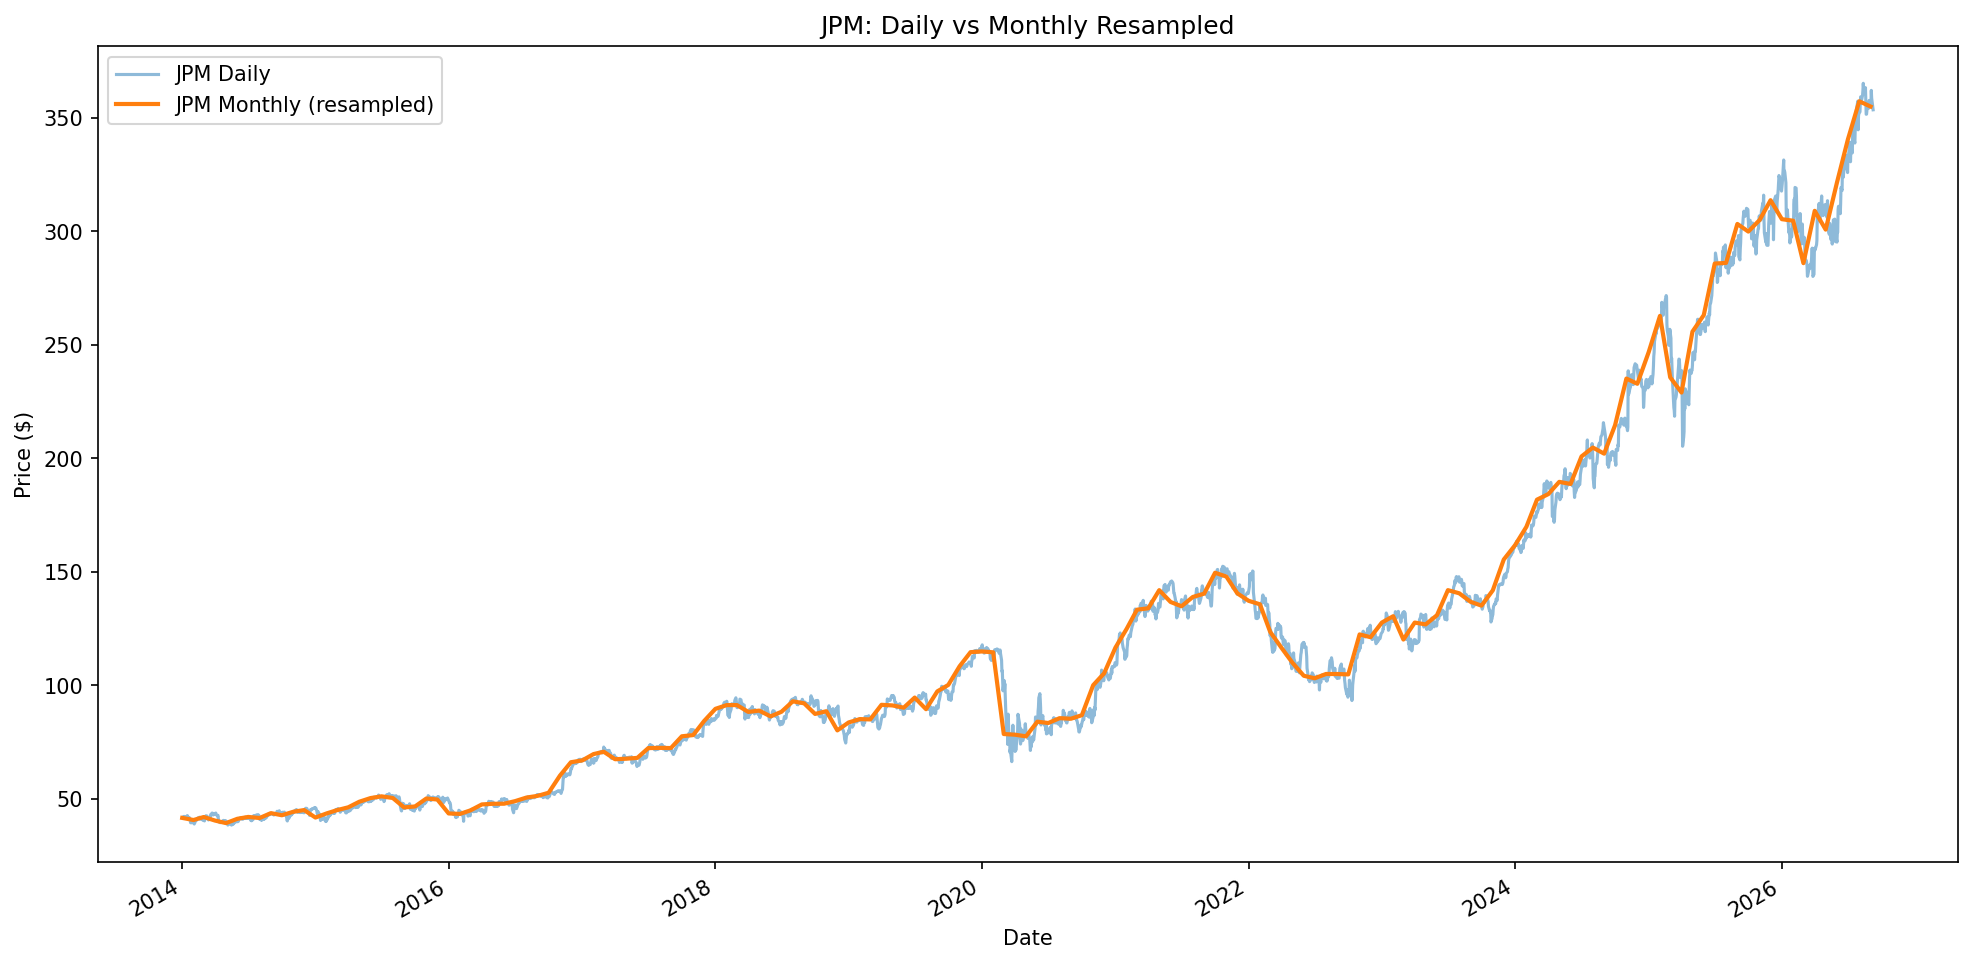

In [ ]:
#Plot monthly data

plt.figure(figsize=(16, 8), dpi=150)

stock_df_multiple['Close_JPM'].plot(label='JPM Daily', alpha=0.5)
df_resample_months['JPM_Spline'].plot(label='JPM Monthly (resampled)', linewidth=2)

plt.title('JPM: Daily vs Monthly Resampled')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.show()

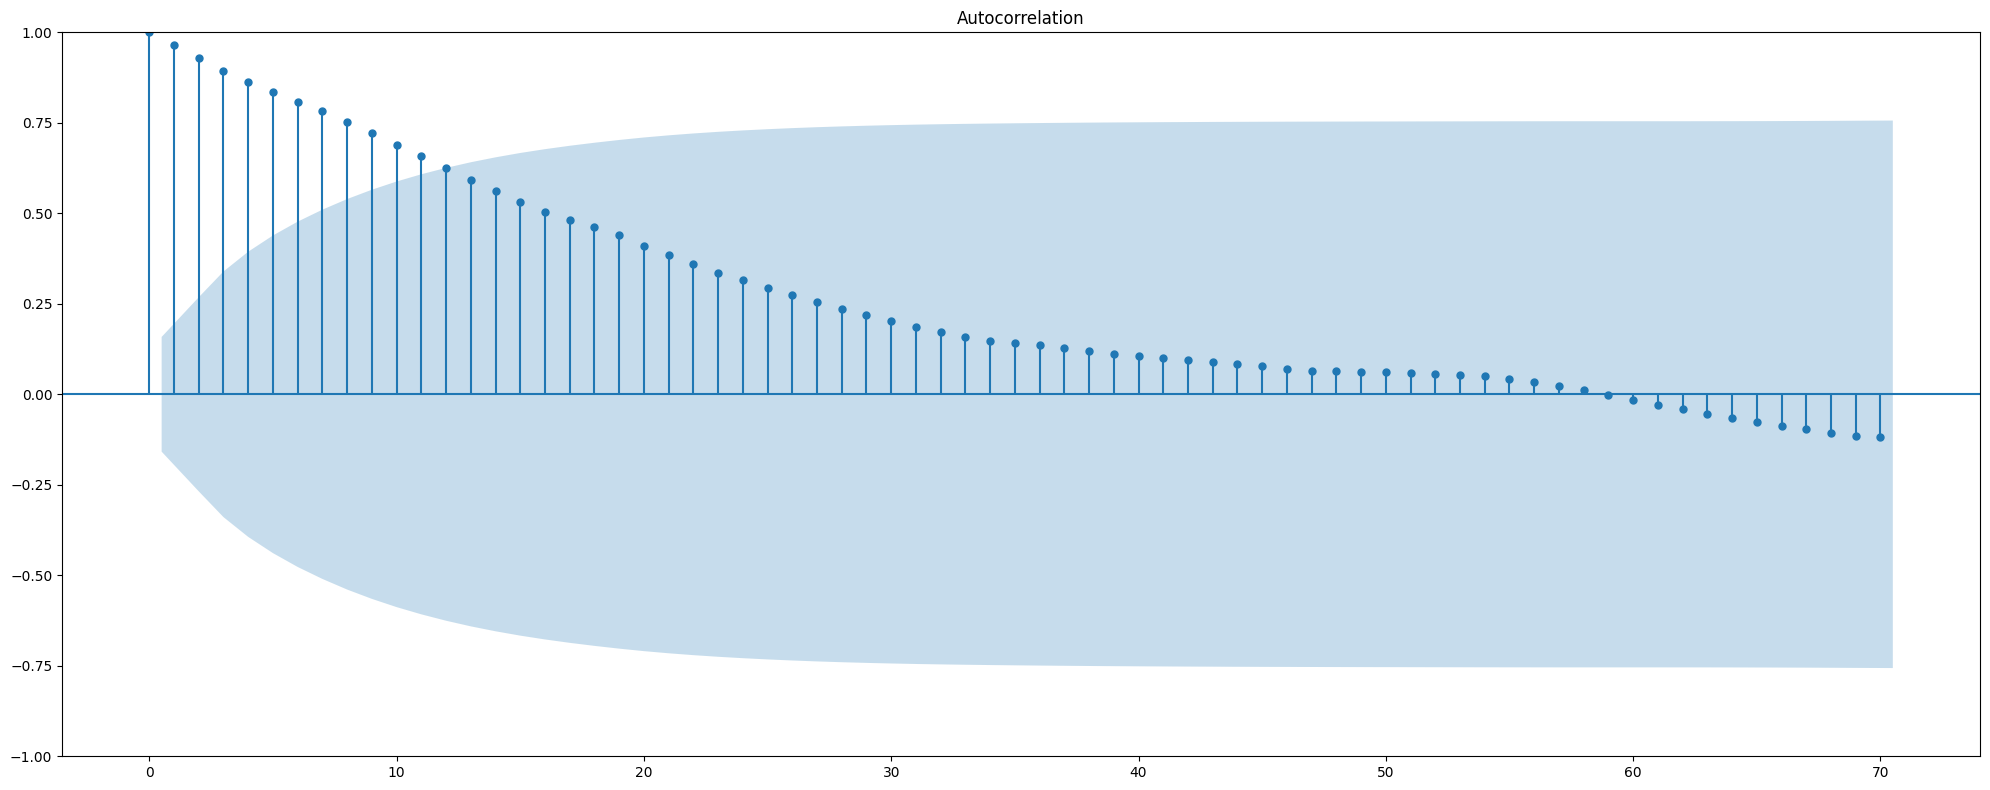

In [ ]:
# Calculate the ACF (via statsmodel)
# Source: https://www.alpharithms.com/autocorrelation-time-series-python-432909/

fig = plot_acf(df_resample_months['JPM_Spline'], lags=70)
fig.set_size_inches((20, 8))
# Tight layout to realign things
fig.tight_layout()
plt.show()

**ACF interpretation**

The autocorrelation starts near 0.97 at lag 1 and decays gradually, remaining
above the 95% confidence band through roughly lag 13. This slow decay is the
signature of a strong trend: because the series drifts persistently upward,
observations close in time are also close in value.

No spikes appear at lags 12, 24, or 36. The decay is smooth rather than
scalloped, confirming the absence of annual seasonality already identified in
the monthly return boxplot.

The series is clearly not white noise, so a forecasting exercise is warranted.

Time series decomposition is a process of deconstructing a time series into the following components:

1. Trend — general movement over time
2. Seasonal — behaviors captured in individual seasonal periods
3. Residual — everything not captured by trend and seasonal components


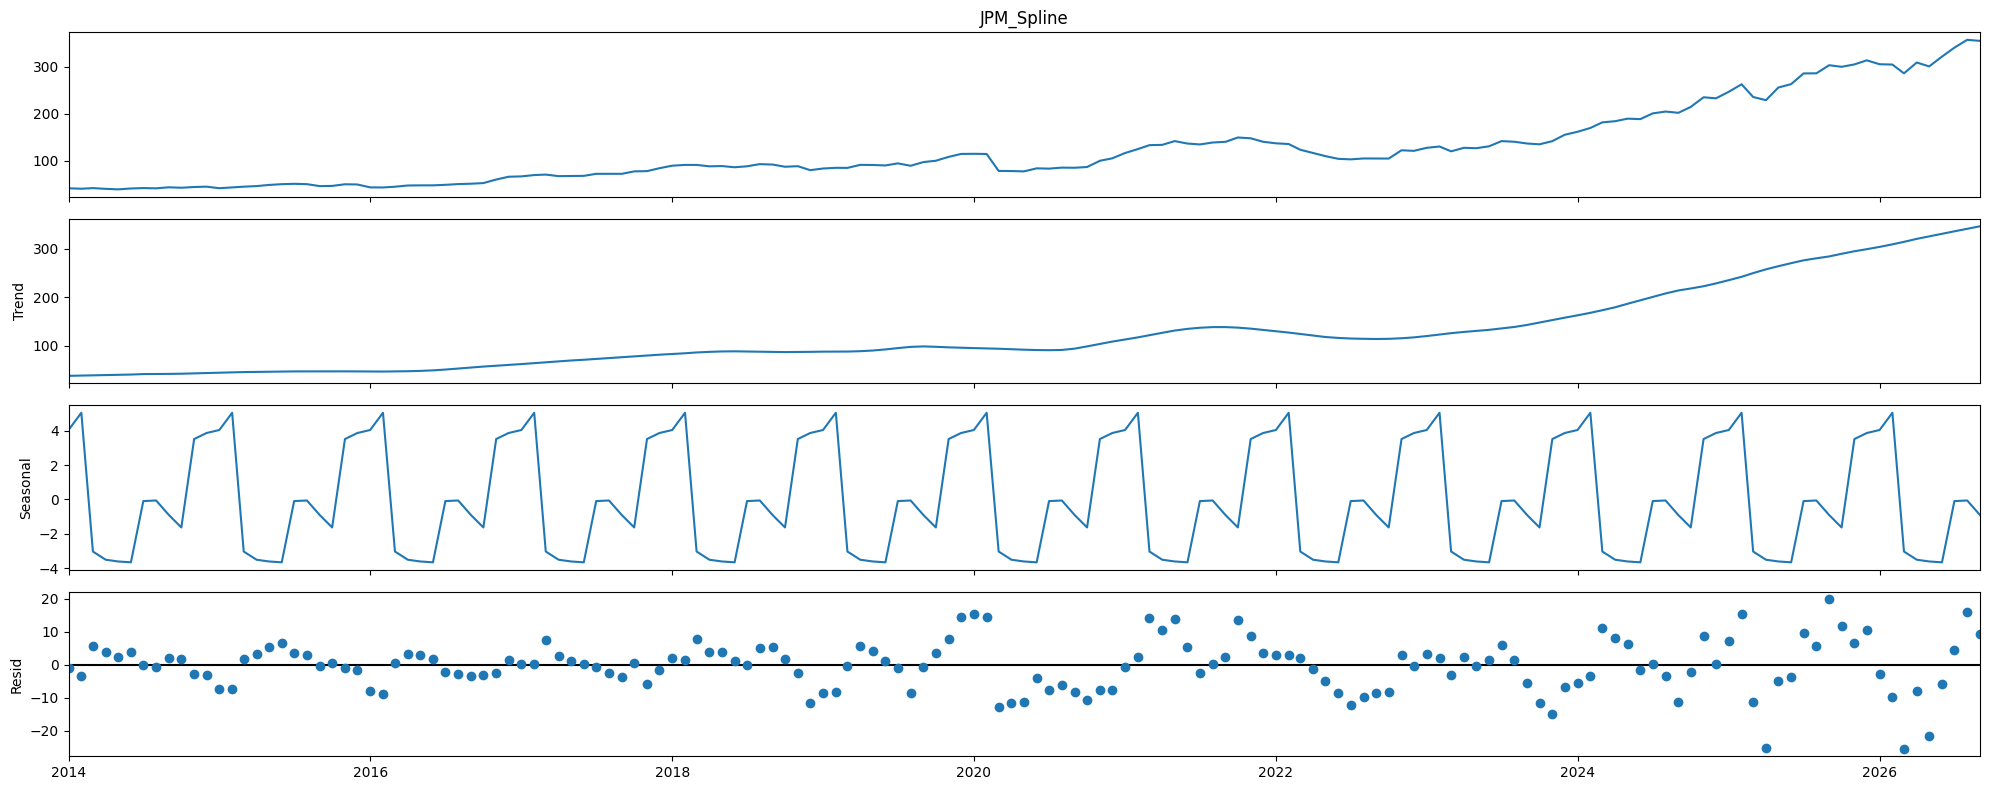

In [ ]:
res = sm.tsa.seasonal_decompose(df_resample_months['JPM_Spline'], period=12, extrapolate_trend='freq')
fig = res.plot()
fig.set_size_inches((20, 8))
# Tight layout to realign things
fig.tight_layout()
plt.show()

In [ ]:
jpm_df = df_resample_months[['JPM_Spline']]

# extract the decomposed terms
jpm_df['trend'] = res.trend
jpm_df['seasonal'] = res.seasonal
jpm_df['error'] = res.resid
jpm_df

,JPM_Spline,trend,seasonal,error
2014-01-01,41.690,38.515898,4.056240,-0.882139
2014-02-01,40.760,39.048325,5.062624,-3.350949
2014-03-01,42.080,39.580751,-3.037226,5.536475
2014-04-01,40.515,40.113177,-3.515636,3.917458
2014-05-01,39.400,40.645604,-3.617051,2.371448
...,...,...,...,...
2026-05-01,300.750,325.746214,-3.617051,-21.379162
2026-06-01,321.520,330.919481,-3.667281,-5.732200
2026-07-01,340.530,336.092749,-0.093421,4.530672
2026-08-01,357.260,341.266017,-0.057599,16.051582


In [ ]:
# Verify that the three components reconstruct the observed series
check = jpm_df['trend'] + jpm_df['seasonal'] + jpm_df['error']
print("Max reconstruction error:", (check - jpm_df['JPM_Spline']).abs().max())

Max reconstruction error: 2.842170943040401e-14


<Axes: >

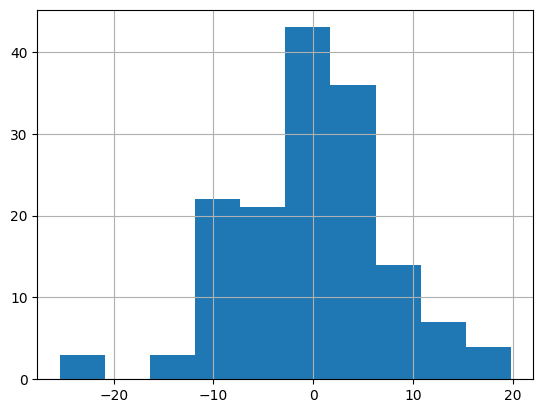

In [ ]:
jpm_df['error'].hist()

In [ ]:
# Figures quoted in the narrative - computed rather than eyeballed
daily = stock_df_multiple_imputed['JPM_Spline']

print("2014 median of daily prices:  $%.2f" % daily[daily.index.year == 2014].median())
print("2026 median of daily prices:  $%.2f" % daily[daily.index.year == 2026].median())
print("Highest daily close in sample: $%.2f" % daily.max())
print("Full-sample mean (imputed constant): $%.2f" % daily.mean())
print("Trend component, first / last: $%.2f / $%.2f"
      % (jpm_df['trend'].iloc[0], jpm_df['trend'].iloc[-1]))
print("Last monthly median: $%.2f" % jpm_df['JPM_Spline'].iloc[-1])

2014 median of daily prices:  $42.04
2026 median of daily prices:  $310.28
Highest daily close in sample: $365.18
Full-sample mean (imputed constant): $123.27
Trend component, first / last: $38.52 / $346.44
Last monthly median: $354.95


**Decomposition results**

**Trend** rises smoothly from roughly 39 to 347 dollars and accounts for nearly all of the variation in the observed series. It ends below the last observed monthly median of 356 dollars because `extrapolate_trend='freq'` fills the endpoint by extending the fitted slope, which lags a sharp recent rally. The 2020 drawdown is smoothed away here and reappears in the residual, since a centred 12-month moving average cannot represent a shock lasting one or two months.

**Seasonal** repeats an identical pattern each year but spans only about 9 dollars, from -4 to +5. Against a price level near 350 dollars this is under 3 percent, and because the additive form applies the same 9 dollar band throughout, the implied seasonal effect would be roughly 20 percent of price in 2014 and 2.5 percent in 2026. Note that `seasonal_decompose` produces a seasonal component whether or not one exists; the relevant question is magnitude, not presence. Read alongside the flat monthly return boxplot and the absence of ACF spikes at lags 12, 24, and 36, this is the third independent indication that JPM has no economically meaningful annual seasonality.

**Residual** is centred at zero with an approximately symmetric distribution, largely contained within plus or minus 15 dollars. The isolated negative deviations correspond to sharp drawdowns that neither trend nor seasonality can explain.

**Implication for model selection.** Because the seasonal component carries negligible magnitude, Triple ETS is expected to fit noise rather than signal.

---

# Q2. Relationship Analysis

**Are the three economic factors good or bad predictors of the stock price?**

The analysis proceeds in three steps: correlation on raw levels, a demonstration
of why that correlation cannot be trusted, and correlation after differencing.

---

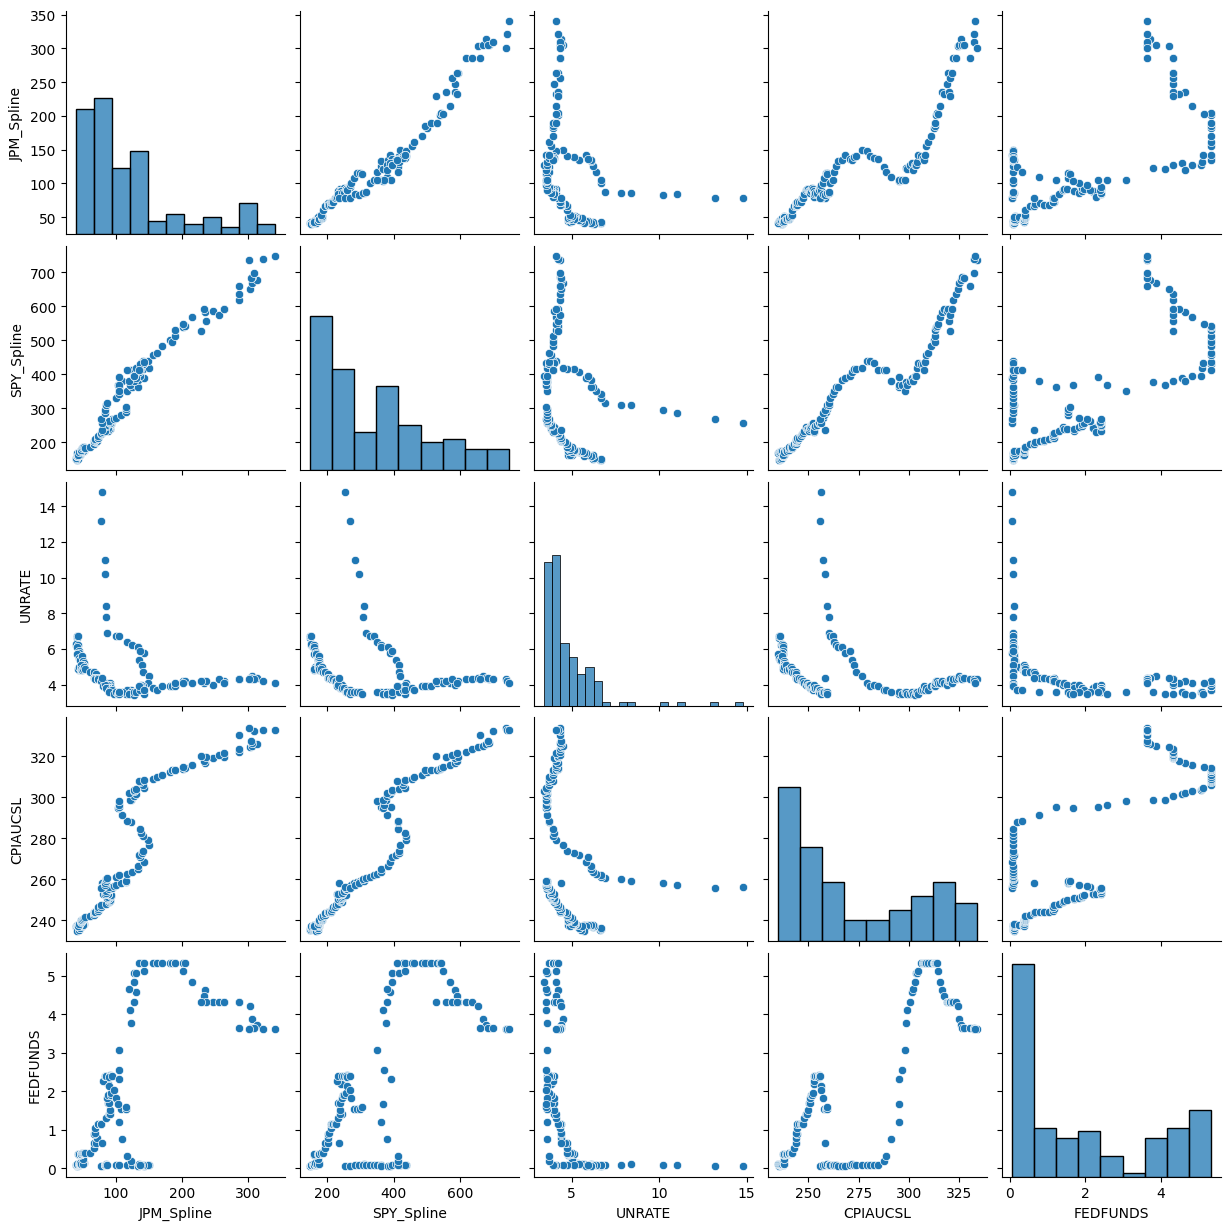

In [ ]:
sns.pairplot(merged)

In [ ]:
# Correlation on raw levels - all variables
merged.corr().round(3)

,JPM_Spline,SPY_Spline,UNRATE,CPIAUCSL,FEDFUNDS
JPM_Spline,1.000,0.977,-0.258,0.911,0.685
SPY_Spline,0.977,1.000,-0.250,0.960,0.705
UNRATE,-0.258,-0.250,1.000,-0.326,-0.483
CPIAUCSL,0.911,0.960,-0.326,1.000,0.824
FEDFUNDS,0.685,0.705,-0.483,0.824,1.000


In [ ]:
# generate two white noise series with 1000 samples each
# set random seed for reproducibility
np.random.seed(42)

wn1 = np.random.normal(size=1000)
wn2 = np.random.normal(size=1000)

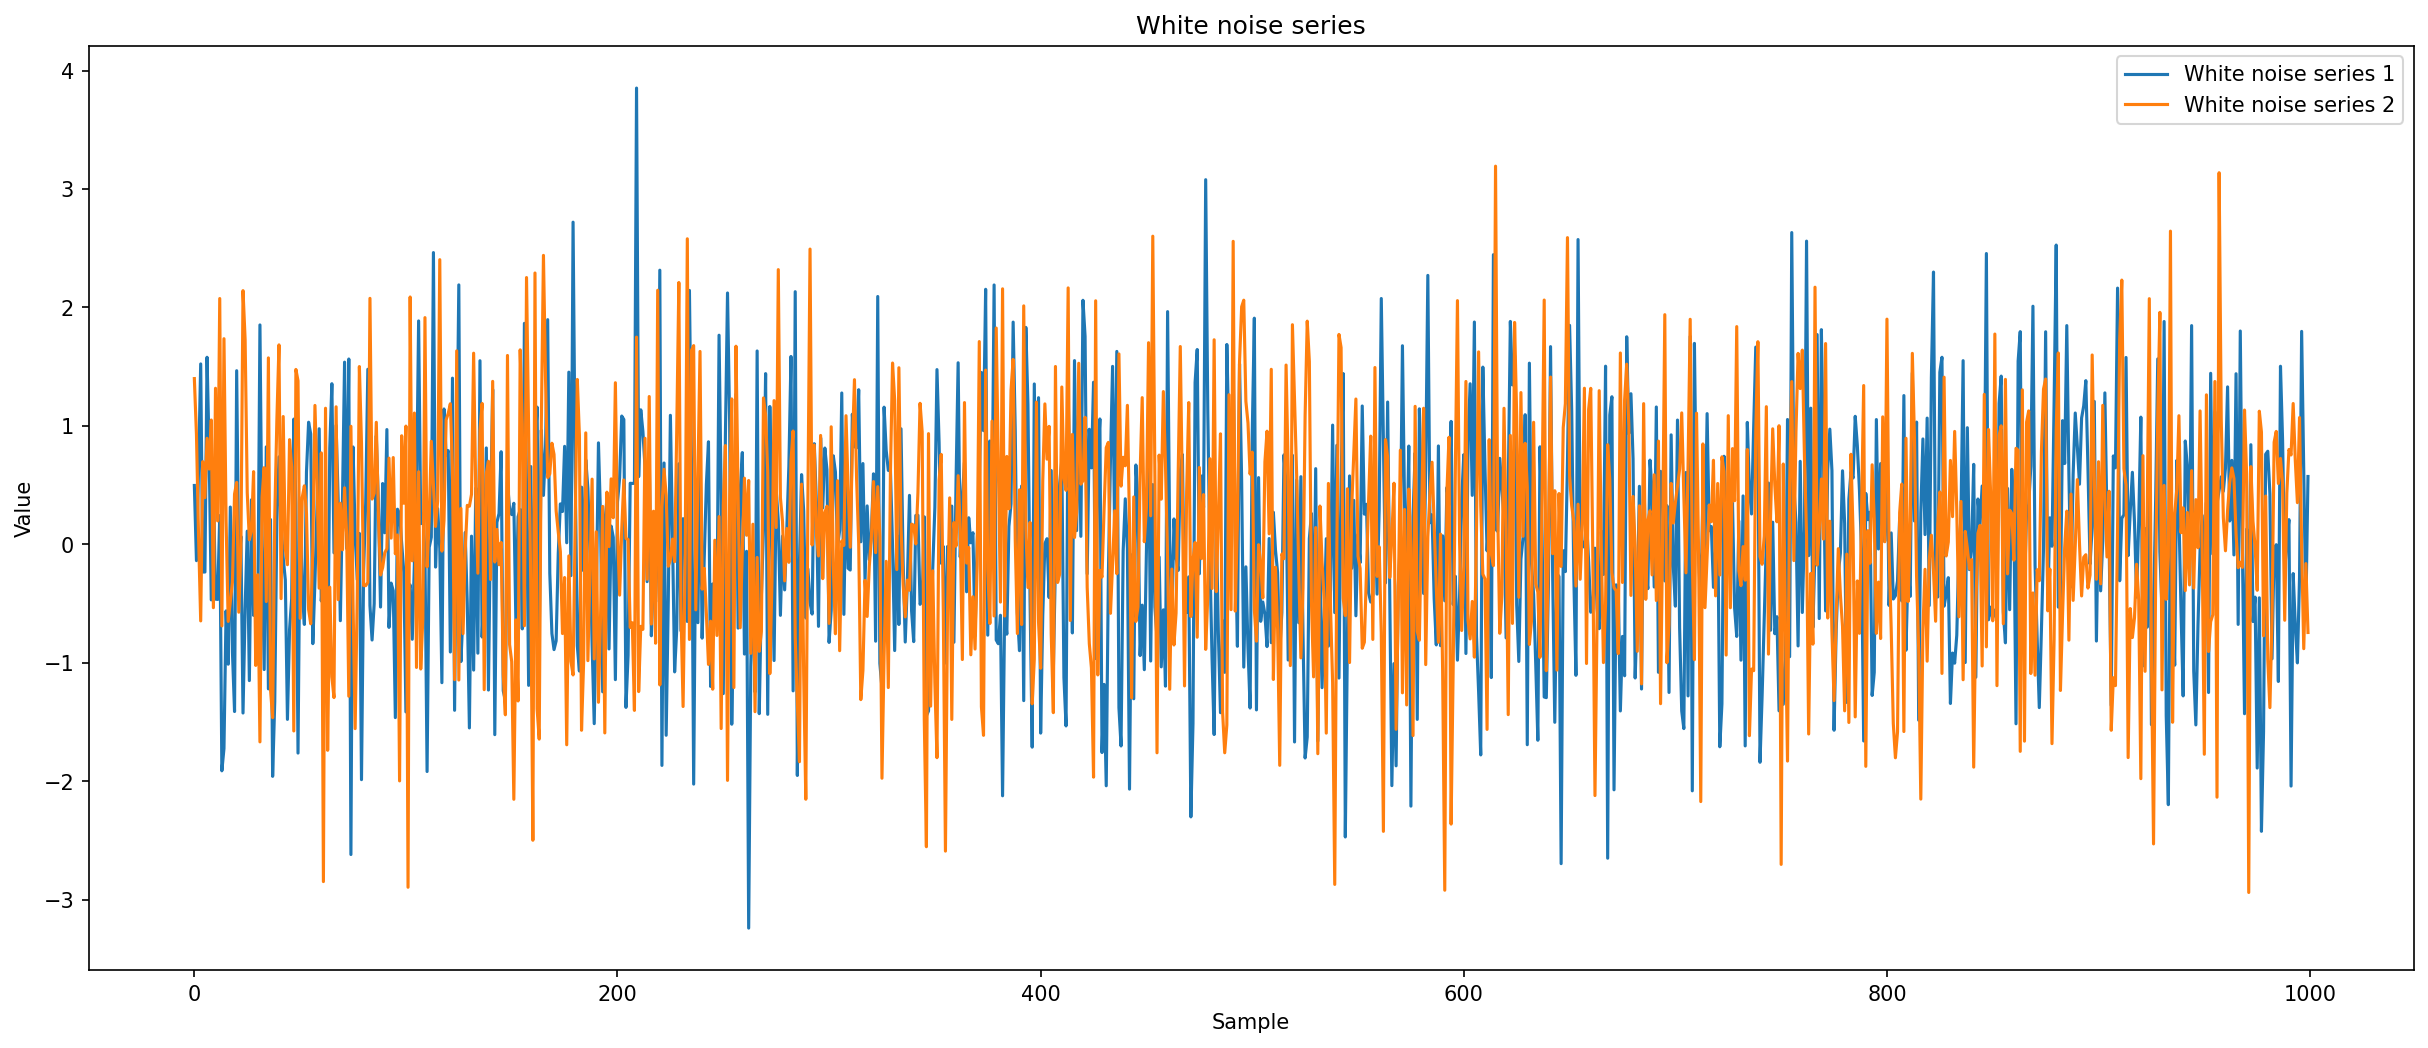

In [ ]:
plt.figure(figsize=(20, 8), dpi=150)

# plot the two white noise series
plt.plot(wn1, label='White noise series 1')
plt.plot(wn2, label='White noise series 2')

# add legend and axis labels
plt.legend()
plt.xlabel('Sample')
plt.ylabel('Value')
plt.title('White noise series')

# show the plot
plt.show()

In [ ]:
# calculate correlation between the two white noise series
corr1 = np.corrcoef(wn1, wn2)[0, 1]
print("Correlation between white noise series: {:.3f}".format(corr1))

Correlation between white noise series: -0.040


In [ ]:
# Now, add a linear trend to both white noise series
trend = np.linspace(0, 10, 1000)
wn1_trend = wn1 + trend
wn2_trend = wn2 + trend

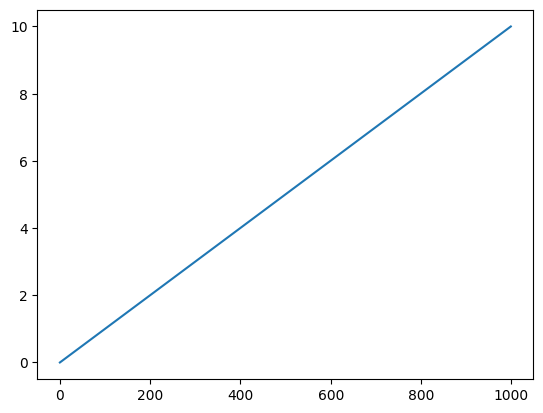

In [ ]:
plt.plot(trend)

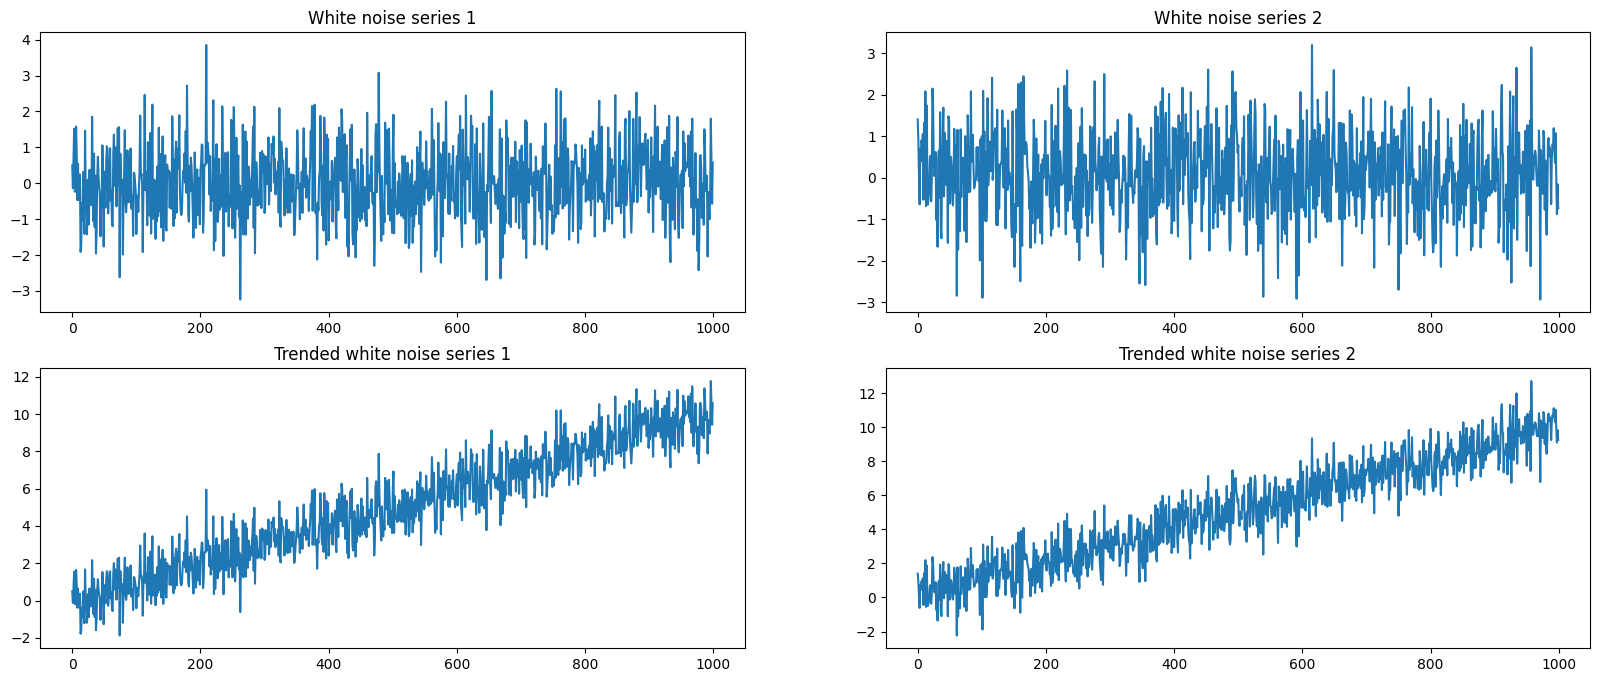

In [ ]:
# plot the white noise series and the trended white noise series
fig, axs = plt.subplots(2, 2, figsize=(20, 8))
axs[0, 0].plot(wn1)
axs[0, 0].set_title("White noise series 1")
axs[0, 1].plot(wn2)
axs[0, 1].set_title("White noise series 2")
axs[1, 0].plot(wn1_trend)
axs[1, 0].set_title("Trended white noise series 1")
axs[1, 1].plot(wn2_trend)
axs[1, 1].set_title("Trended white noise series 2")
plt.show()

In [ ]:
# calculate correlation between the two trended white noise series
corr2 = np.corrcoef(wn1_trend, wn2_trend)[0, 1]
print("Correlation between trended white noise series: {:.3f}".format(corr2))


Correlation between trended white noise series: 0.891


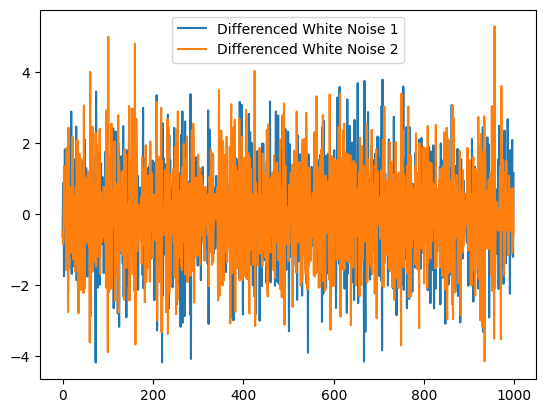

In [ ]:
# Difference the white noise series with trend
diff_1 = np.diff(wn1_trend)
diff_2 = np.diff(wn2_trend)

# Plot the differenced time series
plt.plot(diff_1, label='Differenced White Noise 1')
plt.plot(diff_2, label='Differenced White Noise 2')
plt.legend()
plt.show()

In [ ]:
# Calculate the correlation between the differenced time series
corr_diff = np.corrcoef(diff_1, diff_2)[0, 1]
print(f"The correlation between the differenced time series is {corr_diff}.")

The correlation between the differenced time series is -0.0214771676626417.


In [ ]:
# to escape the spurious correlation trap
# we should difference the time series to detrend it or make it stationary before we check for correlation.

In [ ]:
differenced = merged.diff().dropna()

In [ ]:
differenced

,JPM_Spline,SPY_Spline,UNRATE,CPIAUCSL,FEDFUNDS
2014-02-01,-0.930,-0.180,0.1,0.259,0.00
2014-03-01,1.320,3.330,0.0,0.481,0.01
2014-04-01,-1.565,0.245,-0.5,0.440,0.01
2014-05-01,-1.115,1.565,0.1,0.450,0.00
2014-06-01,1.895,5.740,-0.2,0.313,0.01
...,...,...,...,...,...
2026-03-01,-18.685,-23.225,-0.1,2.833,0.00
2026-04-01,23.050,39.140,0.0,2.114,0.00
2026-05-01,-8.270,38.270,0.0,1.572,-0.01
2026-06-01,20.770,3.150,-0.1,-1.411,0.00


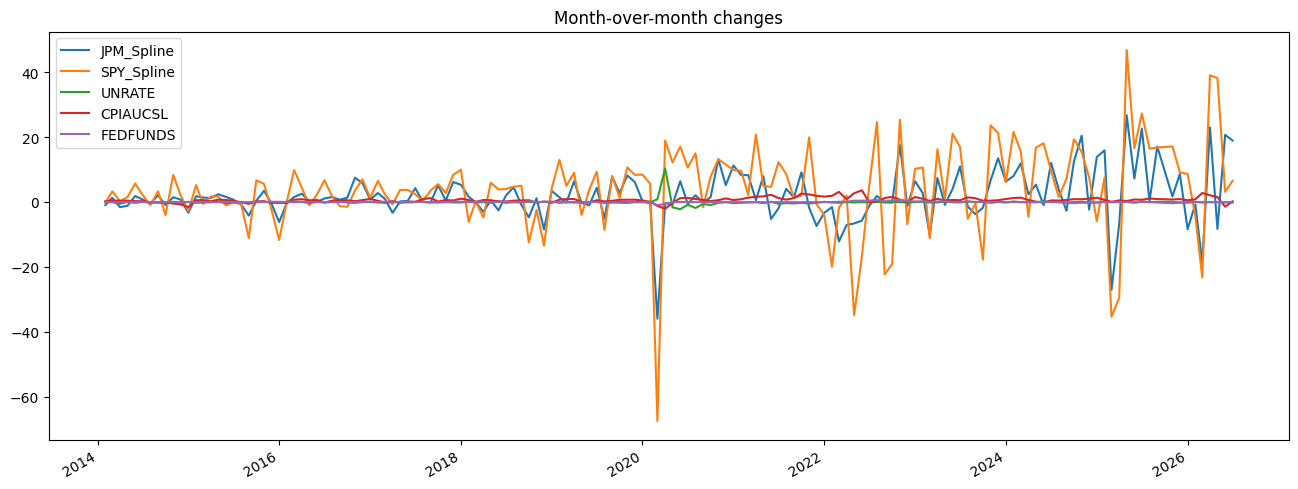

In [ ]:
differenced.plot(figsize=(16,6))
plt.title('Month-over-month changes')
plt.show()

In [ ]:
# Correlation on month-over-month changes - all variables
differenced.corr().round(3)

,JPM_Spline,SPY_Spline,UNRATE,CPIAUCSL,FEDFUNDS
JPM_Spline,1.000,0.687,-0.047,0.022,0.101
SPY_Spline,0.687,1.000,0.019,0.038,0.058
UNRATE,-0.047,0.019,1.000,-0.297,-0.310
CPIAUCSL,0.022,0.038,-0.297,1.000,0.262
FEDFUNDS,0.101,0.058,-0.310,0.262,1.000


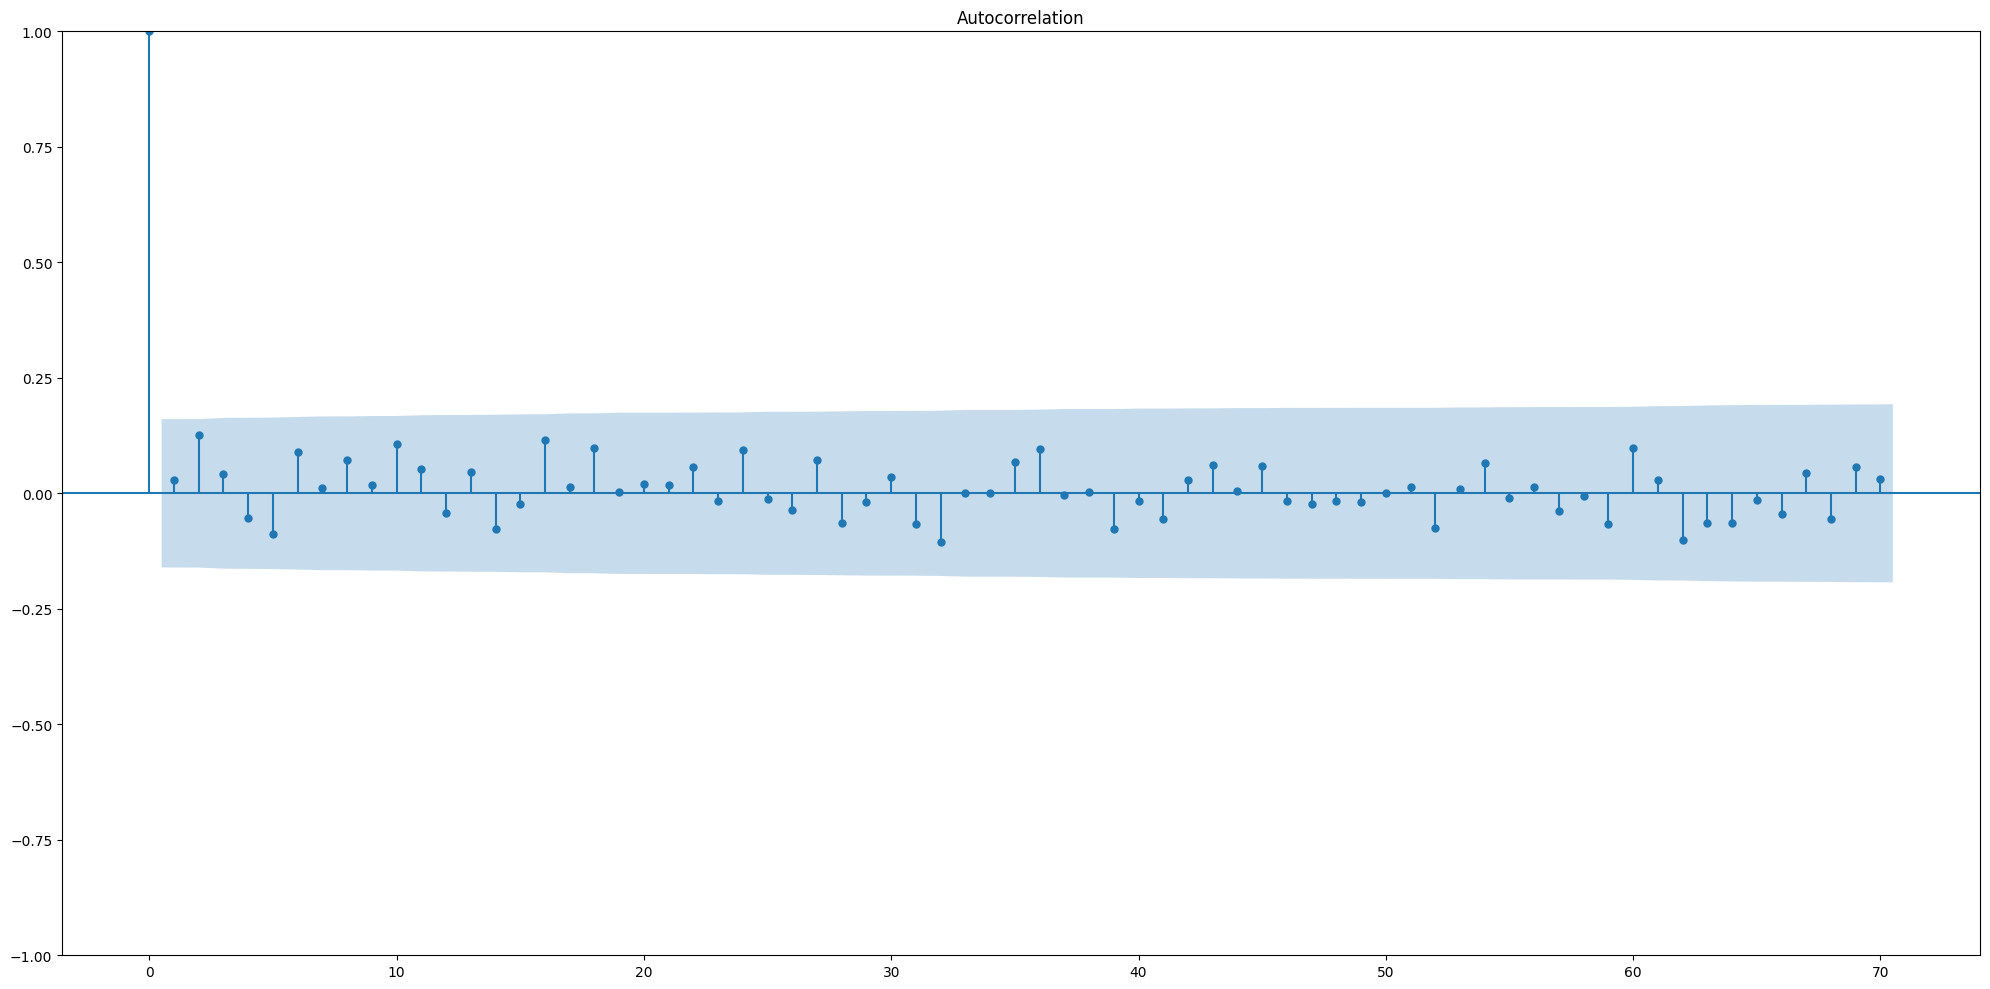

In [ ]:
# Calculate the ACF (via statsmodel)
# Source: https://www.alpharithms.com/autocorrelation-time-series-python-432909/

fig = plot_acf(differenced['JPM_Spline'].dropna(), lags=70)
fig.set_size_inches((20, 10))
# Tight layout to realign things
fig.tight_layout()
plt.show()

After differencing, the autocorrelation falls almost entirely
inside the confidence band. The trend has been removed and the series is close
to stationary.

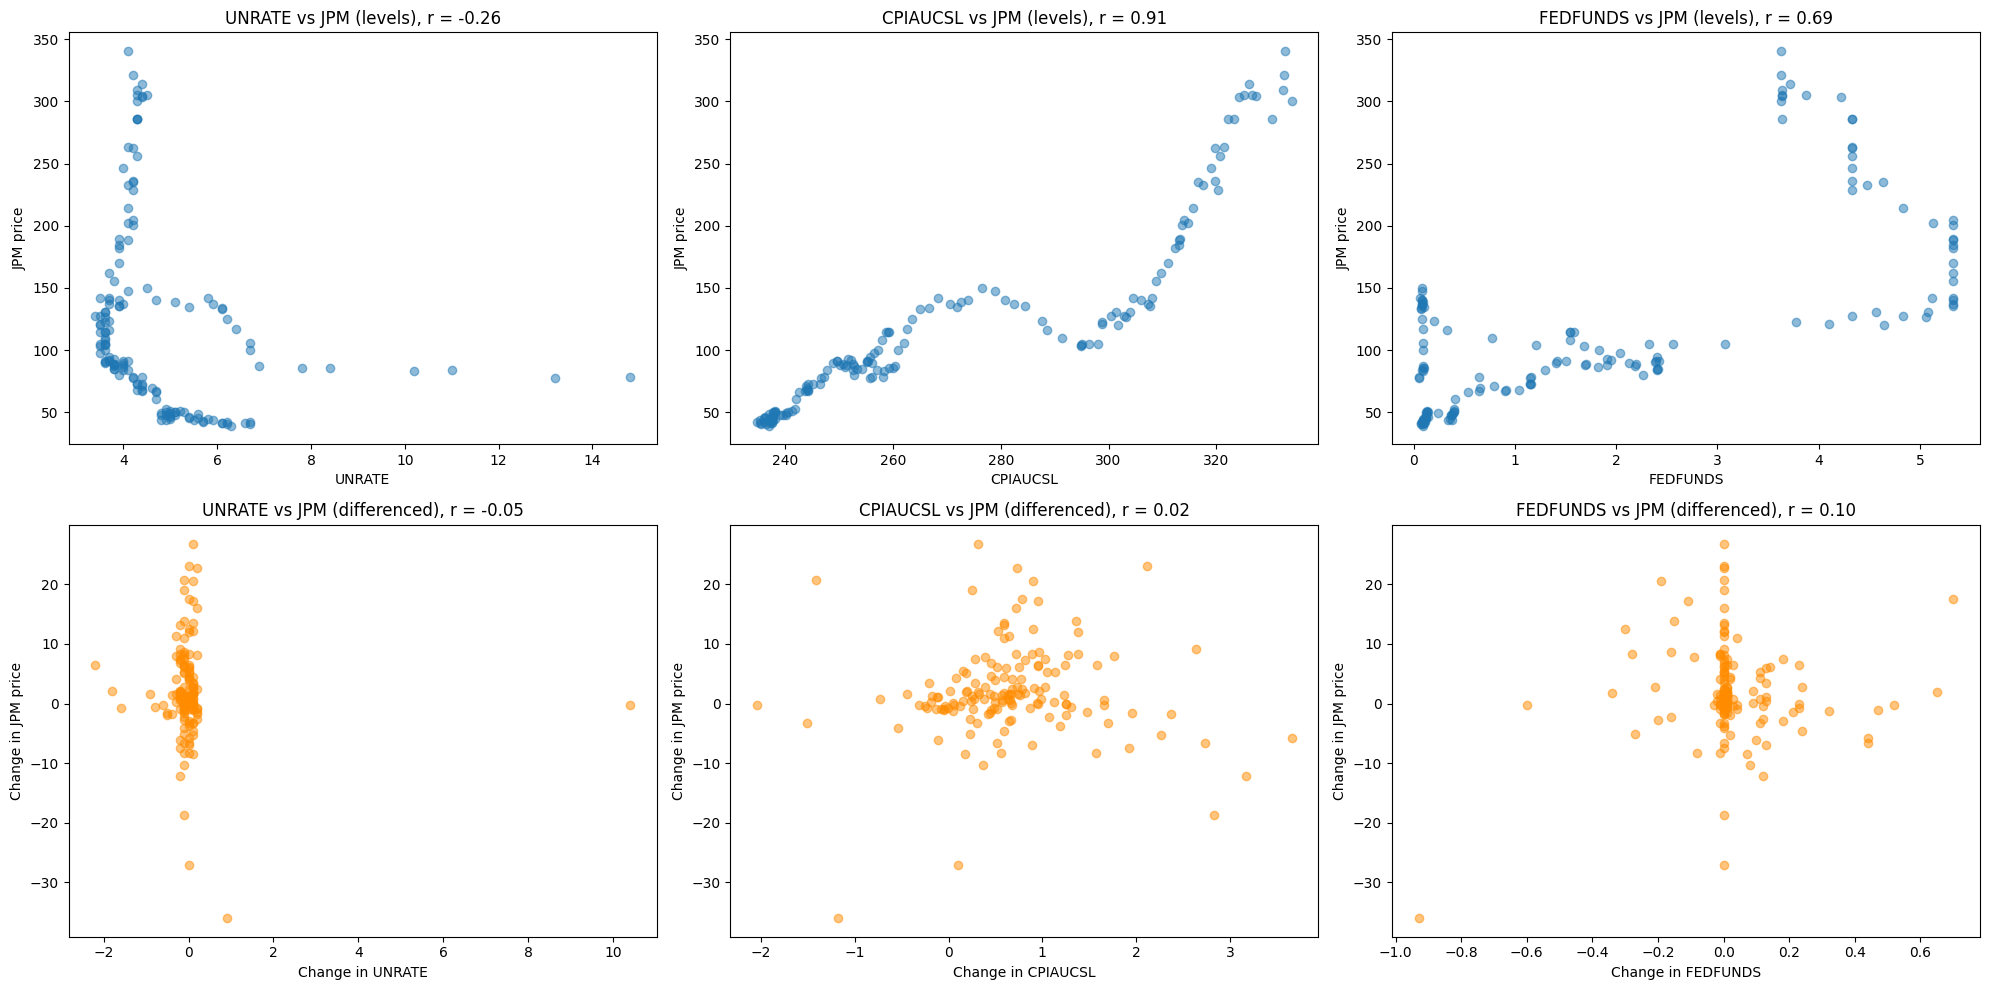

In [ ]:
# Levels vs differences, side by side, for each indicator
factors = ['UNRATE','CPIAUCSL','FEDFUNDS']
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

for i, f in enumerate(factors):
    r_raw = merged[f].corr(merged['JPM_Spline'])
    axes[0, i].scatter(merged[f], merged['JPM_Spline'], alpha=0.5)
    axes[0, i].set_title(f'{f} vs JPM (levels), r = {r_raw:.2f}')
    axes[0, i].set_xlabel(f)
    axes[0, i].set_ylabel('JPM price')

    r_diff = differenced[f].corr(differenced['JPM_Spline'])
    axes[1, i].scatter(differenced[f], differenced['JPM_Spline'],
                       alpha=0.5, color='darkorange')
    axes[1, i].set_title(f'{f} vs JPM (differenced), r = {r_diff:.2f}')
    axes[1, i].set_xlabel(f'Change in {f}')
    axes[1, i].set_ylabel('Change in JPM price')

plt.tight_layout()
plt.show()

In [ ]:
# Summary: correlation before and after differencing
summary = pd.DataFrame({
    'Correlation (levels)':      [merged[f].corr(merged['JPM_Spline']) for f in factors],
    'Correlation (differenced)': [differenced[f].corr(differenced['JPM_Spline'])
                                  for f in factors]
}, index=factors).round(3)

summary

,Correlation (levels),Correlation (differenced)
UNRATE,-0.258,-0.047
CPIAUCSL,0.911,0.022
FEDFUNDS,0.685,0.101


In [ ]:
# Lagged cross-correlation: does a change in the indicator lead a change in JPM?
max_lag = 6
n = len(differenced)
band = 1.96 / np.sqrt(n)

ccf_table = pd.DataFrame(
    {f'lag {k}': [differenced[f].shift(k).corr(differenced['JPM_Spline'])
                  for f in factors]
     for k in range(max_lag + 1)},
    index=factors).round(3)

print(f"95% significance band: +/-{band:.3f}")
outside = [(f, c) for f in factors for c in ccf_table.columns
           if abs(ccf_table.loc[f, c]) > band]
print("Lags outside the band:", outside if outside else "none")

ccf_table

95% significance band: +/-0.161
Lags outside the band: none


,lag 0,lag 1,lag 2,lag 3,lag 4,lag 5,lag 6
UNRATE,-0.047,-0.037,0.053,-0.027,-0.009,-0.049,-0.024
CPIAUCSL,0.022,0.000,-0.089,-0.016,-0.029,-0.014,-0.013
FEDFUNDS,0.101,-0.108,-0.028,0.029,0.054,0.050,0.058


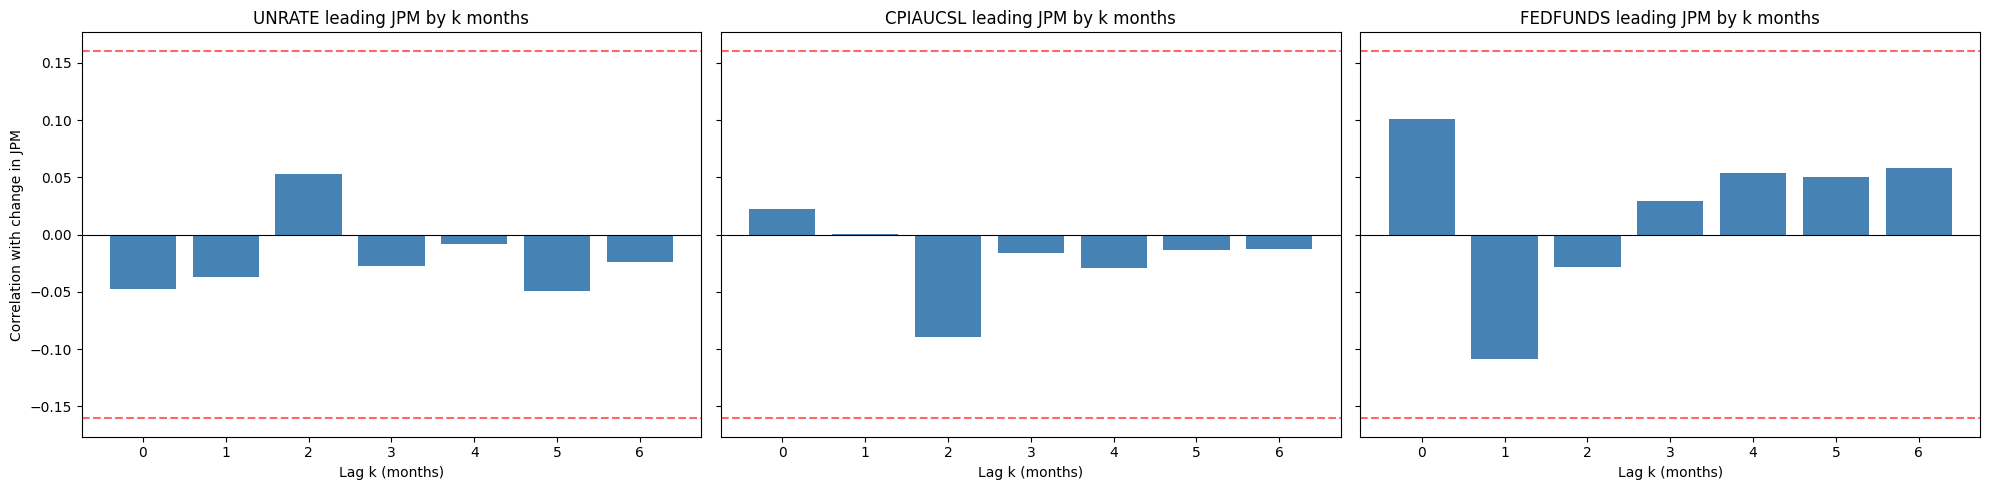

In [ ]:
# Plot the cross-correlations against the 95% band
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)

for ax, f in zip(axes, factors):
    vals = [differenced[f].shift(k).corr(differenced['JPM_Spline'])
            for k in range(max_lag + 1)]
    ax.bar(range(max_lag + 1), vals, color='steelblue')
    ax.axhline(band, color='red', linestyle='--', alpha=0.6)
    ax.axhline(-band, color='red', linestyle='--', alpha=0.6)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f'{f} leading JPM by k months')
    ax.set_xlabel('Lag k (months)')

axes[0].set_ylabel('Correlation with change in JPM')
plt.tight_layout()
plt.show()

**Does the relationship appear at a lag?**

Contemporaneous correlation is the wrong test for a predictor. If an indicator carries information, it should move before JPM does, so the relevant question is whether a change in the indicator at month t-k moves with the change in JPM at month t.

The table reports that correlation for k = 0 through 6, against a 95 percent band of plus or minus 0.161 at this sample size. No lag clears the band for any of the three indicators; the largest value anywhere in the grid is -0.108, for the federal funds rate at a one-month lead.

This closes the gap left by the contemporaneous test. The indicators are not merely coincident with JPM without predicting it; they carry no usable lead either.

## Q2 Verdict

**Correlation on raw levels is misleading.** Measured on price and index levels, JPM shows a strong positive correlation with CPI and the federal funds rate. Taken at face value this would suggest the indicators are excellent predictors.

**The white noise experiment above shows why this is unreliable.** Two independent random series, correlated at essentially zero, produce a correlation of approximately 0.89 once the same linear trend is added to both. Nothing about their relationship changed; only their shared direction did. Correlating non-stationary series measures common drift, not association.

**After differencing, the relationships largely disappear.** Once both JPM and the indicators are expressed as month-over-month changes, the correlations collapse toward zero. The apparent strength on levels was an artifact of the fact that JPM, CPI, and rates all trended upward across the sample period.

**All three are poor predictors of monthly JPM price movements.** This is not a failure of variable selection. Each indicator has a defensible economic link to bank profitability, but three mechanisms limit predictive value at monthly frequency:

1. **Publication lag.** The indicators are released one to two months after the reference period, so the information is not available at the point a forecast would need to be made.
2. **Anticipation.** Equity markets price in expectations of macroeconomic data before release, so the announcement itself carries limited new information.
3. **Frequency mismatch.** Monthly aggregation is too coarse to capture the market reaction, which occurs within hours of publication.

The lagged cross-correlation above rules out the simplest counterargument, that the relationship exists but is merely offset in time.

**Consequence for the forecasting task.** Since none of the three indicators provides usable incremental signal at this frequency, the univariate approach required by the assignment is also the analytically appropriate one.

## Split data into train and test sets

---

# Q3. Univariate Forecasting

Economic factors are **not** forecast, in line with the assignment instructions.
Only the JPM monthly median price is modelled.

---

In [ ]:
jpm = jpm_df[['JPM_Spline']]
jpm

,JPM_Spline
2014-01-01,41.690
2014-02-01,40.760
2014-03-01,42.080
2014-04-01,40.515
2014-05-01,39.400
...,...
2026-05-01,300.750
2026-06-01,321.520
2026-07-01,340.530
2026-08-01,357.260


In [ ]:
# Create a test set of 12 data points
test_size = 12

train_data = jpm.iloc[:-test_size]
test_data  = jpm.iloc[-test_size:]

print(f"No. of training examples: {train_data.shape[0]}")
print(f"No. of testing examples: {test_data.shape[0]}")
print(f"Test period: {test_data.index.min().date()} to {test_data.index.max().date()}")

No. of training examples: 141
No. of testing examples: 12
Test period: 2025-10-01 to 2026-09-01


In [ ]:
train_data

,JPM_Spline
2014-01-01,41.690
2014-02-01,40.760
2014-03-01,42.080
2014-04-01,40.515
2014-05-01,39.400
...,...
2025-05-01,255.830
2025-06-01,263.110
2025-07-01,285.800
2025-08-01,286.080


In [ ]:
test_data

,JPM_Spline
2025-10-01,299.890
2025-11-01,304.970
2025-12-01,313.690
2026-01-01,305.340
2026-02-01,304.655
2026-03-01,285.970
2026-04-01,309.020
2026-05-01,300.750
2026-06-01,321.520
2026-07-01,340.530


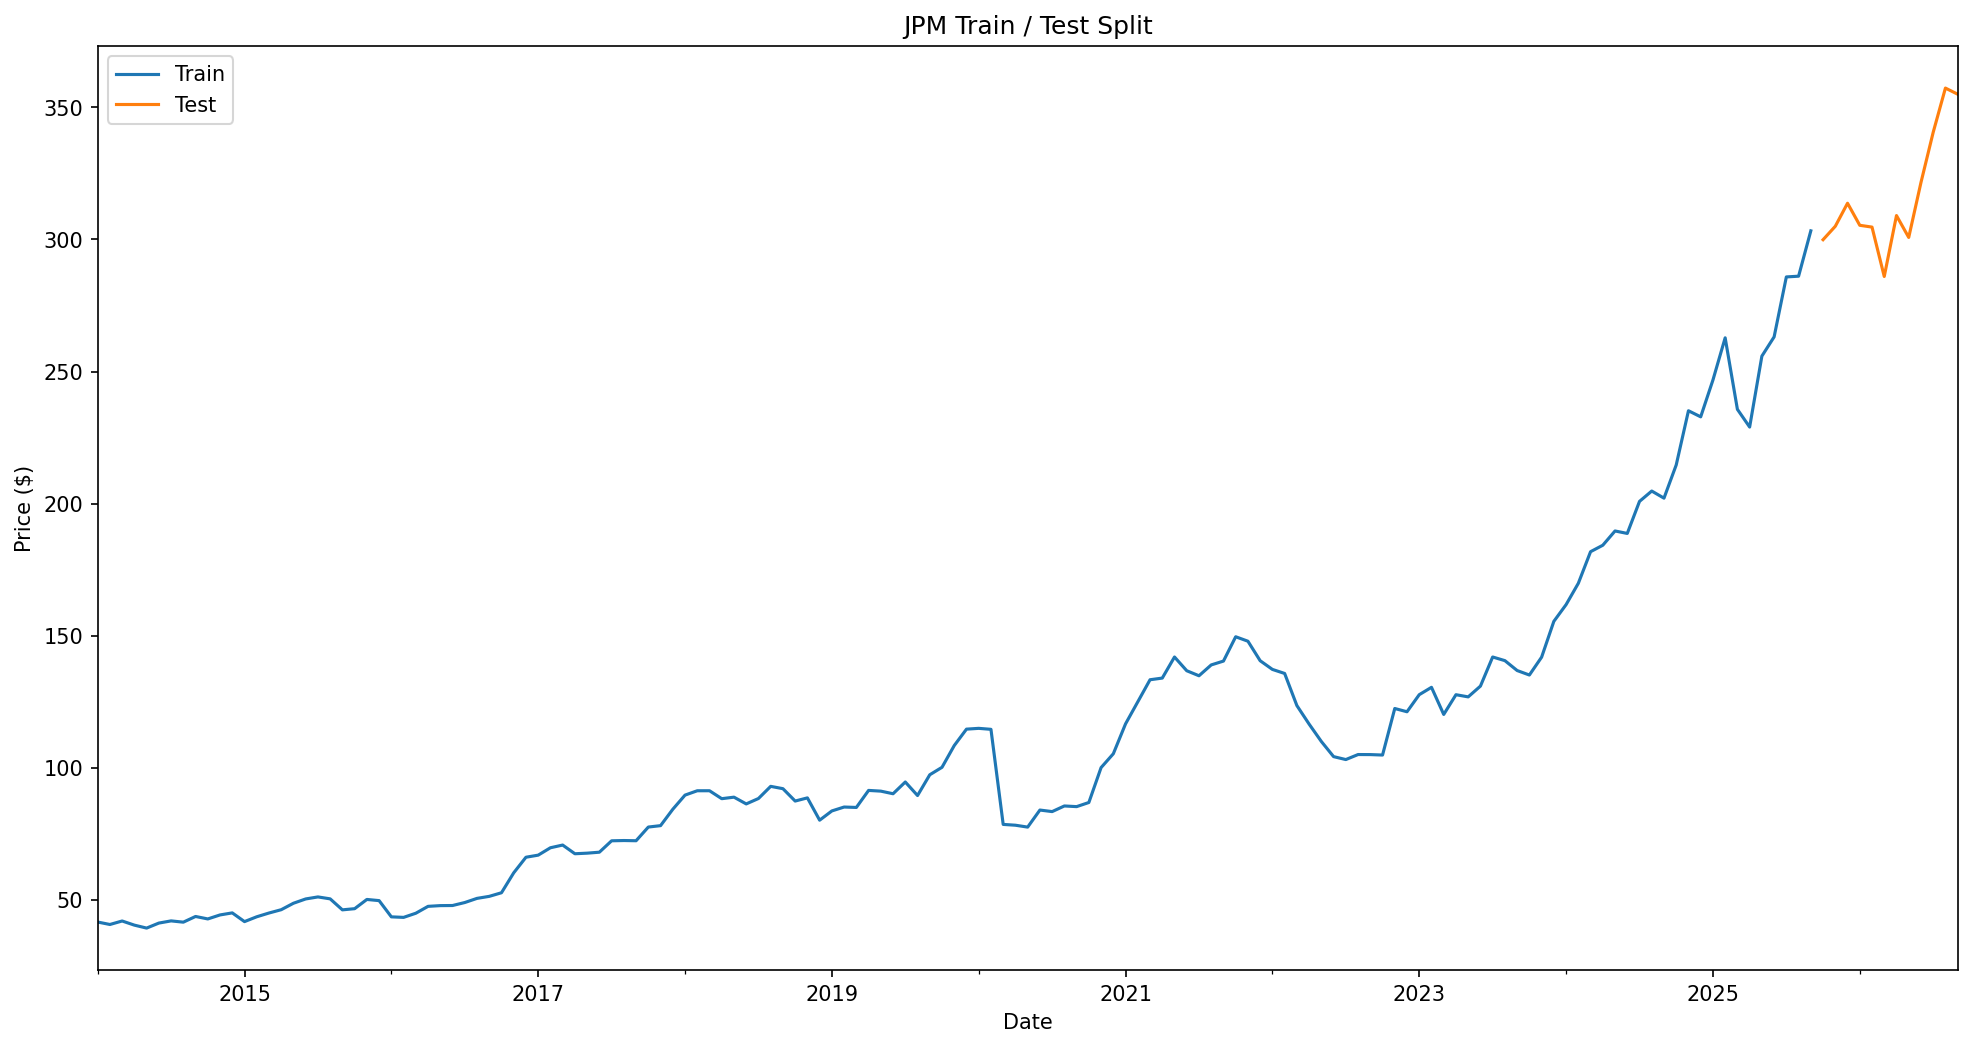

In [ ]:
#Plot train and test data

plt.figure(figsize=(16, 8), dpi=150)

train_data['JPM_Spline'].plot(label='Train')
test_data['JPM_Spline'].plot(label='Test')

plt.title('JPM Train / Test Split')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.show()

## Fitting Models - Exponential Smoothing Models

### ETS - Error, Trend, Seasonailty

Exponential smoothing was proposed in the late 1950s, and has motivated some of the most successful forecasting methods. Exponential smoothing is a time series forecasting method for univariate data. Forecasts produced using exponential smoothing methods are weighted averages of past observations, with the weights decaying exponentially as the observations get older. In other words, the more recent the observation the higher the associated weight.

The weights are controlled by the smoothing parameter which is known as 'alpha'. alpha value can be between 0 to 1:

1. (alpha)=0: Means that forecast for future value is the average of historical data.
2. (alpha)=1: Means that forecast for all future value is the value of the last observation   

Source:
1. https://analyticsindiamag.com/hands-on-guide-to-time-series-analysis-using-simple-exponential-smoothing-in-python/#:~:text=Simple%20Exponential%20Smoothing%20(SES)%20is,statsmodel%20using%20pip%20install%20statsmodel.&text=Simple%20Exponential%20Smoothing%20is%20defined,where%20we%20will%20import%20it.
2. https://machinelearningmastery.com/exponential-smoothing-for-time-series-forecasting-in-python/

#### Simple Exponential Smoothing

The simplest of the exponentially smoothing methods is naturally called simple exponential smoothing (SES). This method is suitable for forecasting data with no clear trend or seasonal pattern.

For creating a prediction model using SES we should have an (alpha) value which can be hyper parameter tuned. Here we will create three instances in which we will take three different (alpha) values as:

1. (alpha) = 0.2
2. (alpha) = 0.5
3. (alpha) value automatically optimized by statsmodel which is the recommended one.

We will pass the data into Simple Exponential Smoothing and fit the data with different values of the Smoothing Level.

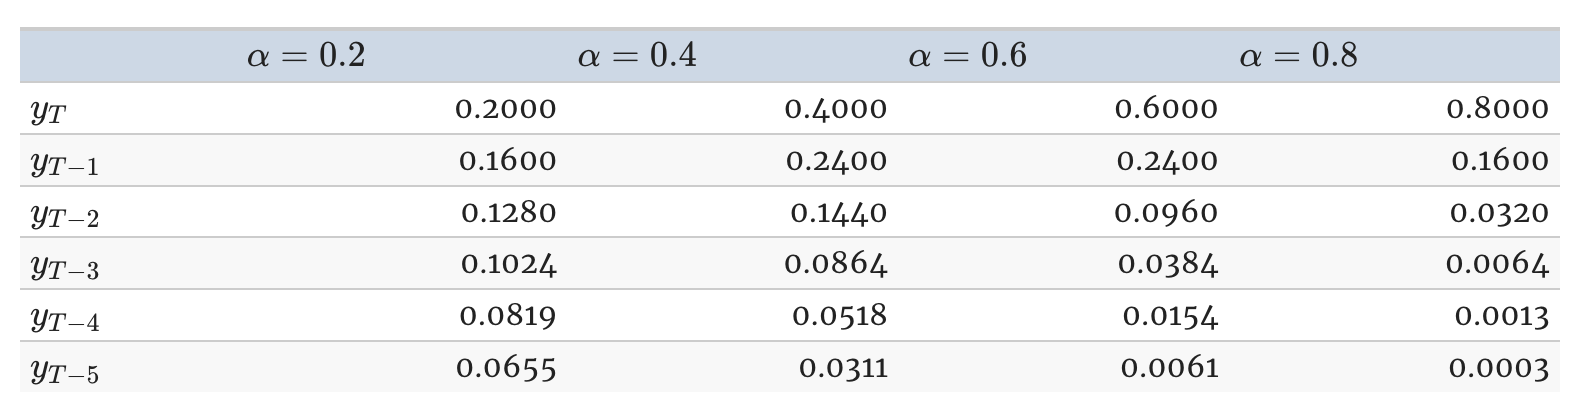

In [ ]:
#First Instance
ins1 = SimpleExpSmoothing(train_data).fit(smoothing_level=0.2,optimized=False)
ins_cast1 = ins1.forecast(12).rename('alpha=0.2')

#Second Instance
ins2 = SimpleExpSmoothing(train_data).fit(smoothing_level=0.5,optimized=False)
ins_cast2 = ins2.forecast(12).rename('alpha=0.5')

#Third Instance - alpha optimised by statsmodels
ins3 = SimpleExpSmoothing(train_data).fit()
alpha_opt = ins3.model.params['smoothing_level']
ins_cast3 = ins3.forecast(12).rename('alpha=%.3f' % alpha_opt)

print("Optimised alpha:", round(alpha_opt, 4))

Optimised alpha: 1.0


In [ ]:
ins_cast1

,alpha=0.2
2025-10-01,265.376564
2025-11-01,265.376564
2025-12-01,265.376564
2026-01-01,265.376564
2026-02-01,265.376564
2026-03-01,265.376564
2026-04-01,265.376564
2026-05-01,265.376564
2026-06-01,265.376564
2026-07-01,265.376564


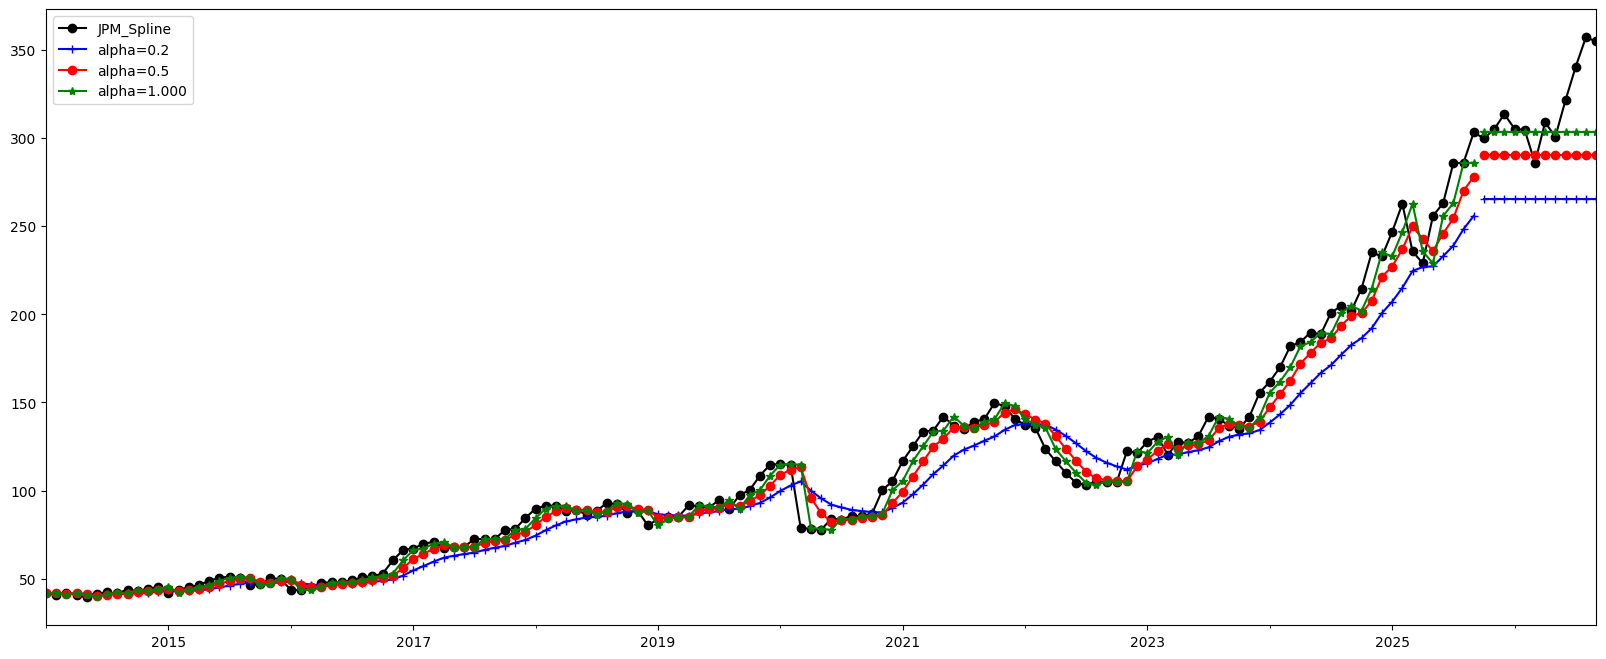

In [ ]:
#After creating model we will visualize the plot
ax = jpm.plot(marker='o', color='black', figsize=(20,8), legend=True)

#Plot for alpha =0.2
ins_cast1.plot(marker='+', ax=ax, color='blue', legend=True)
ins1.fittedvalues.plot(marker='+', ax=ax, color='blue')

#Plot for alpha = 0.5
ins_cast2.plot(marker='o', ax=ax, color='red', legend=True)
ins2.fittedvalues.plot(marker='o', ax=ax, color='red')

#Plot for alpha=Optimized by statsmodel
ins_cast3.plot(marker='*', ax=ax, color='green', legend=True)
ins3.fittedvalues.plot(marker='*', ax=ax, color='green')

plt.show()

In [ ]:
'''
In terms of forecasting, simple exponential smoothing generates a constant set of values.
All forecasts equal the last value of the level component.
Consequently, these forecasts are appropriate only when your time series data have no trend or seasonality.
'''

'\nIn terms of forecasting, simple exponential smoothing generates a constant set of values.\nAll forecasts equal the last value of the level component.\nConsequently, these forecasts are appropriate only when your time series data have no trend or seasonality.\n'

#### Double Exponential Smoothing

This is the extended version of simple exponential smoothing to allow the forecasting of data with a trend. This method has two smoothing equations and hence two parameters, alpha and beta, (one for the level and one for the trend).

In [ ]:
# Double ETS
# Let us fit the data on Double ES, on both Additive and Multiplicative Trend

In [ ]:
double_ets_add = ExponentialSmoothing(train_data, trend = 'add').fit()
double_ets_mul = ExponentialSmoothing(train_data, trend = 'mul').fit()

double_ets_add_pred = double_ets_add.forecast(12)
double_ets_mul_pred = double_ets_mul.forecast(12)


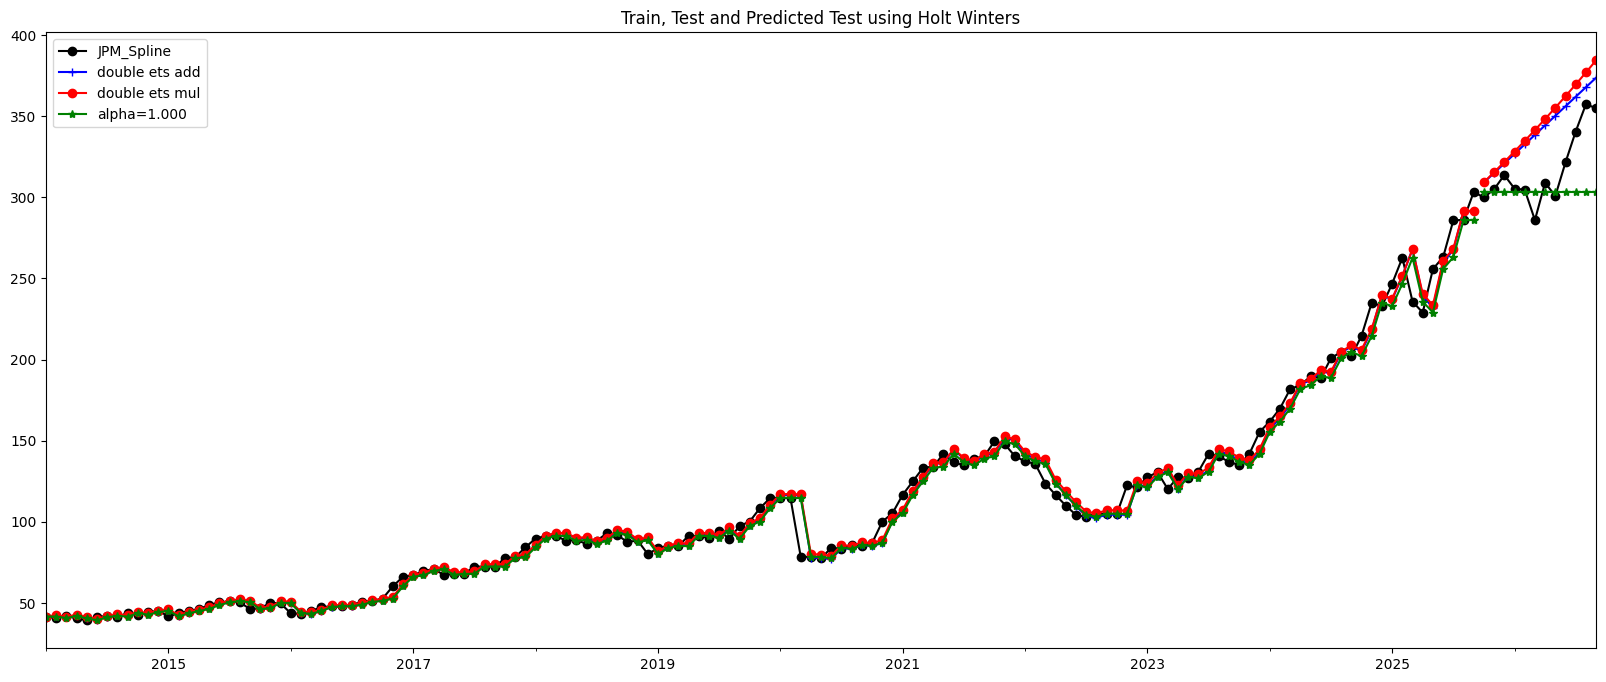

In [ ]:
#plot the train, test, and predictions

#After creating model we will visualize the plot
ax = jpm.plot(marker='o', color='black', figsize=(20,8), legend=True)

#Plot for double ETS additive
double_ets_add_pred.plot(marker='+', ax=ax, color='blue', legend=True, label = 'double ets add')
double_ets_add.fittedvalues.plot(marker='+', ax=ax, color='blue')

#Plot for double ETS multiplicative
double_ets_mul_pred.plot(marker='o', ax=ax, color='red', legend=True, label = 'double ets mul')
double_ets_mul.fittedvalues.plot(marker='o', ax=ax, color='red')

#Plot for simple exponential smooting alpha=Optimized by statsmodel
ins_cast3.plot(marker='*', ax=ax, color='green', legend=True)
ins3.fittedvalues.plot(marker='*', ax=ax, color='green')
plt.title('Train, Test and Predicted Test using Holt Winters')
plt.show()



#### Triple Exponential Smoothing

This is the extended version of simple exponential smoothing to allow the forecasting of data with a trend and seasonality. This method has three smoothing equations and hence three parameters - alpha, beta, and gamma. (one each for the level, trend, and seasonality).

In [ ]:
# triple ETS - Holt Winter's Seasonal Method
triple_ets_add = ExponentialSmoothing(train_data, trend='add', seasonal='add',
                                      seasonal_periods=12).fit()
triple_ets_add_pred = triple_ets_add.forecast(12)

try:
    triple_ets_mul = ExponentialSmoothing(train_data, trend='mul', seasonal='mul',
                                          seasonal_periods=12).fit()
    triple_ets_mul_pred = triple_ets_mul.forecast(12)
    print("Both triple ETS specifications fitted.")
except Exception as e:
    print("Multiplicative triple ETS failed to converge:", e)
    triple_ets_mul_pred = None

Both triple ETS specifications fitted.


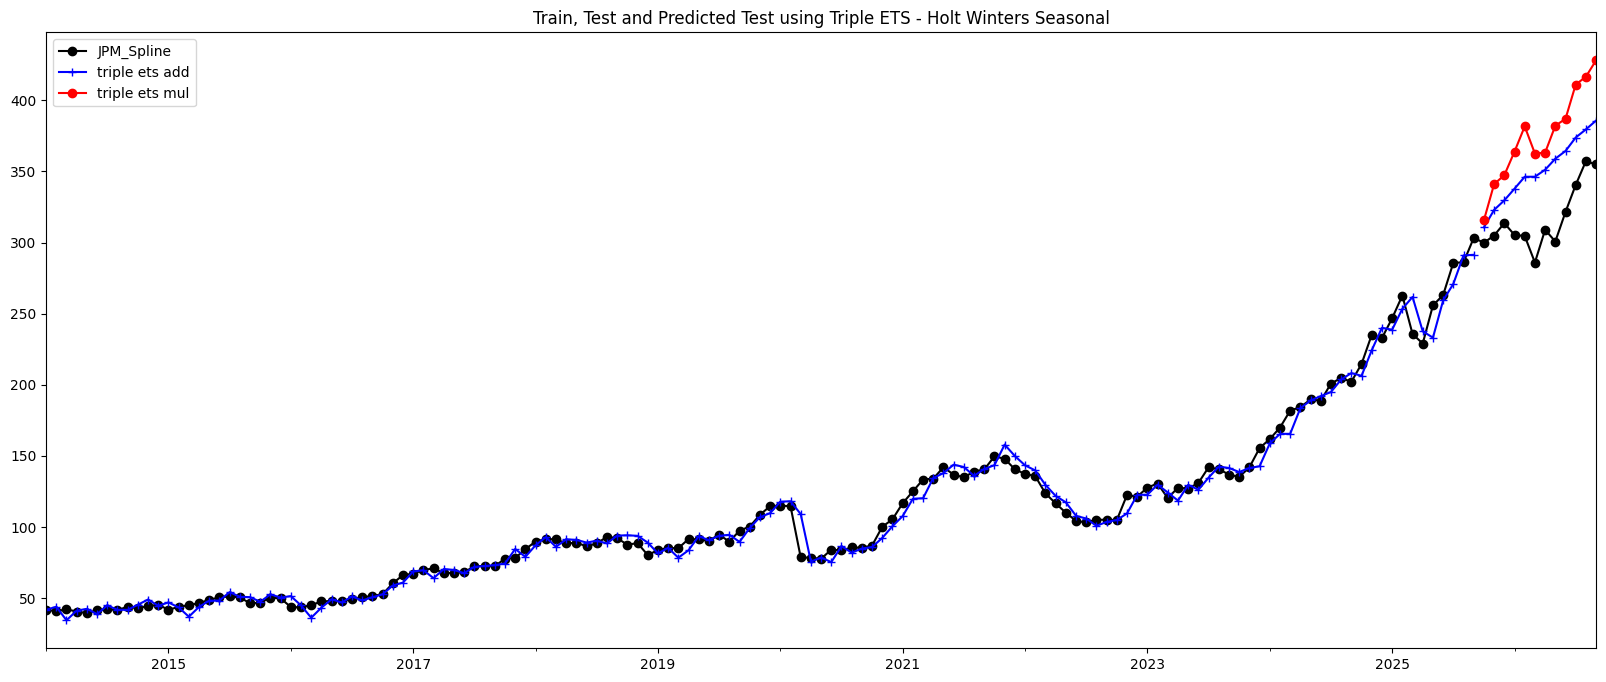

In [ ]:
#plot the train, test, and predictions

ax = jpm.plot(marker='o', color='black', figsize=(20,8), legend=True)

triple_ets_add_pred.plot(marker='+', ax=ax, color='blue', legend=True,
                         label='triple ets add')
triple_ets_add.fittedvalues.plot(marker='+', ax=ax, color='blue')

if triple_ets_mul_pred is not None:
    triple_ets_mul_pred.plot(marker='o', ax=ax, color='red', legend=True,
                             label='triple ets mul')

plt.title('Train, Test and Predicted Test using Triple ETS - Holt Winters Seasonal')
plt.show()

## Visualize Forecast Errors

Source: https://machinelearningmastery.com/visualize-time-series-residual-forecast-errors-with-python/

In [ ]:
# Residual Plots / Residual Diagnostics. What are residuals?

In [ ]:
#calculate residuals
residuals = test_data.values.flatten() - double_ets_add_pred.values.flatten()
residuals = pd.DataFrame(residuals, columns=['residual'])

In [ ]:
residuals

,residual
0,-9.224512
1,-10.014023
2,-7.163535
3,-21.383047
4,-27.937559
5,-52.492071
6,-35.311582
7,-49.451094
8,-34.550606
9,-21.410118


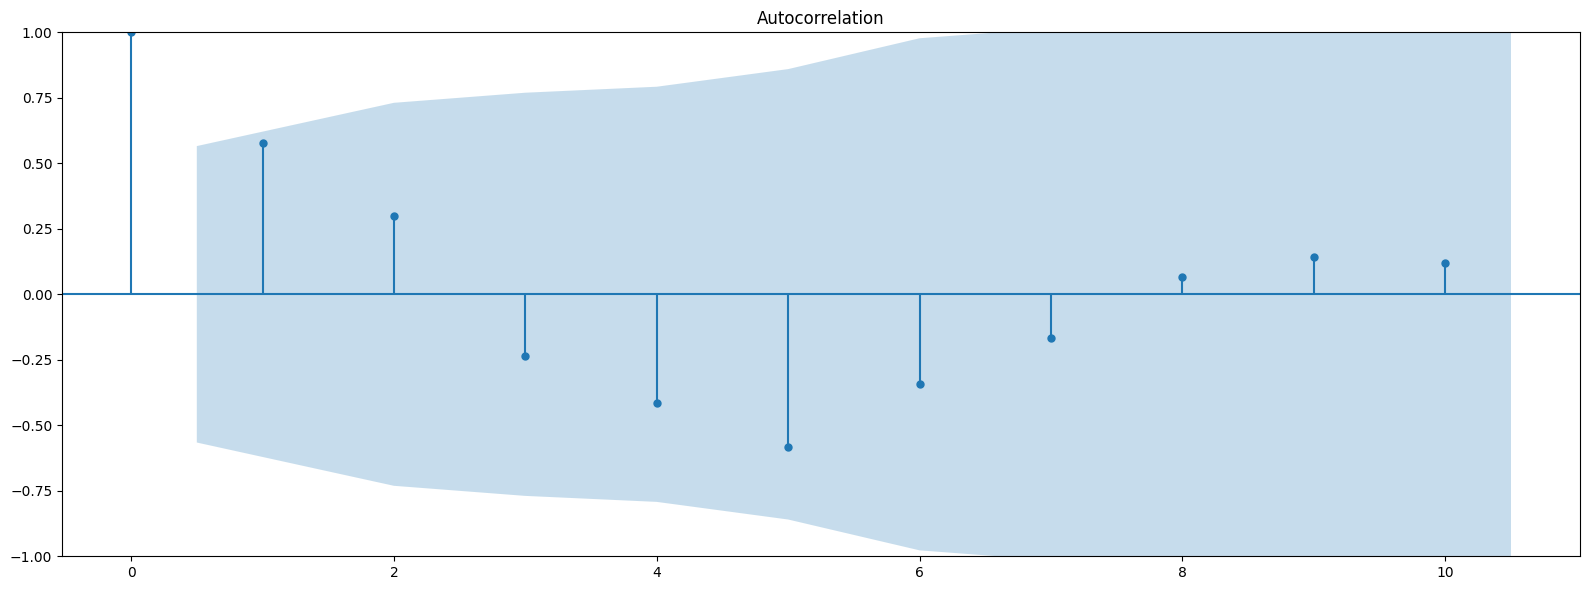

In [ ]:
fig = plot_acf(residuals, lags=min(10, len(residuals)-1))
fig.set_size_inches((16, 6))
fig.tight_layout()
plt.show()

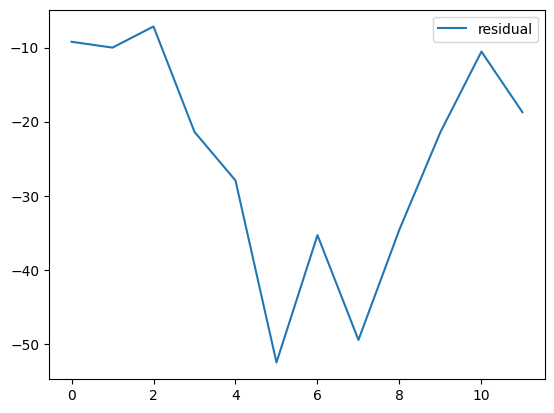

In [ ]:
# plot residuals
residuals.plot()
plt.show()

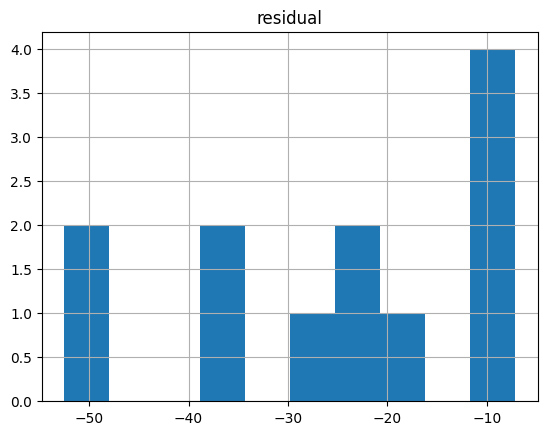

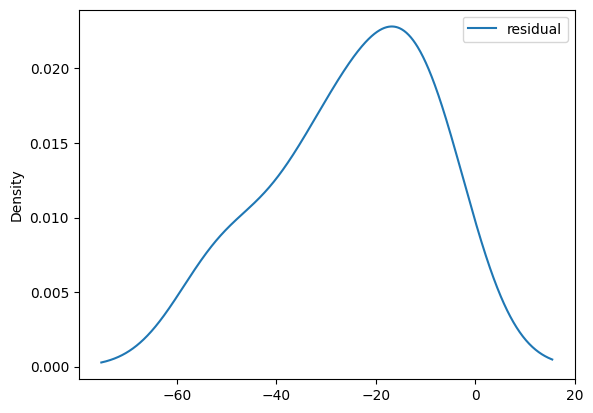

In [ ]:
# histogram plot
residuals.hist()
plt.show()
# density plot
residuals.plot(kind='kde')
plt.show()

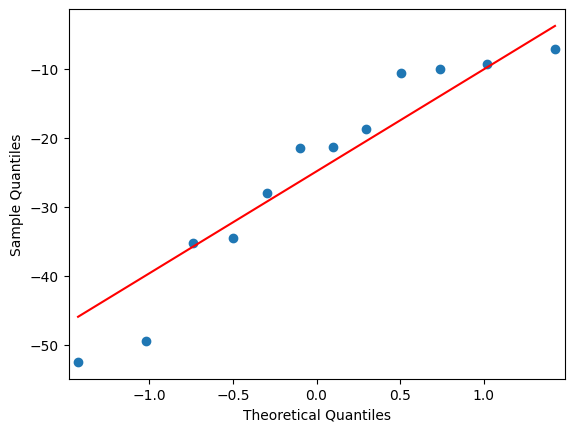

In [ ]:
qqplot(residuals['residual'], line='s')
plt.show()

### Metrics - model evaluation

1. Root Mean Squared Error (RMSE) represents the sample standard deviation of the differences between predicted values and observed values. These individual differences are called residuals when the calculations are performed over the data sample that was used for estimation, and are called prediction errors when computed out-of-sample. This is a great measurement to use when comparing models as it shows how many deviations from the mean the forecasted values fall.
2. Mean Absolute Error (MAE) takes the sum of the absolute difference from actual to forecast and averages them. It is less sensitive to the occasional very large error because it does not square the errors in the calculation.
3. Mean Absolute Percentage Error (MAPE) is also often useful for purposes of reporting, because it is expressed in generic percentage terms it will make sense even to someone who has no idea what constitutes a "big" error in terms of dollars spent or widgets sold.

### Two additional accuracy metrics

**MASE (Mean Absolute Scaled Error).** RMSE, MAE and MAPE report how large the error is, not whether the forecast was worth making. MASE divides the forecast MAE by the MAE of a naive one-step forecast on the training set, giving a benchmark-relative and scale-free figure. For a near-random-walk price series that benchmark is deliberately hard to beat. One caveat applies below: the conventional threshold of 1 assumes a one-step forecast, so at a twelve-month horizon the explicit naive row in the table, not 1.0, is the comparison point.

**sMAPE (symmetric Mean Absolute Percentage Error).** MAPE divides by the actual value, so an over-forecast is unbounded while an under-forecast is capped at 100 percent. On a trending series that quietly rewards models which under-forecast. sMAPE divides by the average of actual and predicted, removing the asymmetry.

In [ ]:
def mase(actual, predicted, train_series):
    """Mean Absolute Scaled Error - scaled by naive one-step MAE on the training set."""
    naive_mae = np.mean(np.abs(np.diff(train_series)))
    return np.mean(np.abs(actual - predicted)) / naive_mae


def smape(actual, predicted):
    """Symmetric Mean Absolute Percentage Error."""
    denominator = (np.abs(actual) + np.abs(predicted)) / 2
    return np.mean(np.abs(actual - predicted) / denominator) * 100


train_values = train_data.values.flatten()

metrics_rows = []
metrics_dataframe = pd.DataFrame(columns=['Model', 'RMSE', 'MAE', 'MAPE', 'MASE', 'sMAPE'])


def metrics_cal(actuals, predictions, model):
    global metrics_dataframe
    actuals = np.asarray(actuals, dtype=float)
    predictions = np.asarray(predictions, dtype=float)

    metrics_rows.append({
        'Model': model,
        'RMSE':  sqrt(mean_squared_error(actuals, predictions)),
        'MAE':   mean_absolute_error(actuals, predictions),
        'MAPE':  np.mean(np.abs((actuals - predictions) / actuals)) * 100,
        'MASE':  mase(actuals, predictions, train_values),
        'sMAPE': smape(actuals, predictions)})

    metrics_dataframe = pd.DataFrame(metrics_rows)
    return metrics_dataframe

In [ ]:
actuals = test_data.values.flatten()

metrics_cal(actuals, ins_cast1.values.flatten(),           'SES alpha=0.2')
metrics_cal(actuals, ins_cast2.values.flatten(),           'SES alpha=0.5')
metrics_cal(actuals, ins_cast3.values.flatten(),           'SES optimised')
metrics_cal(actuals, double_ets_add_pred.values.flatten(), 'Double ETS additive')
metrics_cal(actuals, double_ets_mul_pred.values.flatten(), 'Double ETS multiplicative')
metrics_cal(actuals, triple_ets_add_pred.values.flatten(), 'Triple ETS additive')

if triple_ets_mul_pred is not None:
    metrics_cal(actuals, triple_ets_mul_pred.values.flatten(), 'Triple ETS multiplicative')

metrics_dataframe.round(3)

,Model,RMSE,MAE,MAPE,MASE,sMAPE
0,SES alpha=0.2,55.587,51.169,15.787,10.820,17.339
1,SES alpha=0.5,33.776,26.652,8.033,5.636,8.553
2,SES optimised,25.467,17.155,5.102,3.628,5.358
3,Double ETS additive,28.920,24.851,8.025,5.255,7.601
4,Double ETS multiplicative,32.943,29.073,9.307,6.148,8.771
5,Triple ETS additive,37.316,34.107,10.930,7.212,10.245
6,Triple ETS multiplicative,61.703,58.541,18.516,12.379,16.789


In [ ]:
metrics_dataframe.round(3).sort_values(by='MAE')

,Model,RMSE,MAE,MAPE,MASE,sMAPE
2,SES optimised,25.467,17.155,5.102,3.628,5.358
3,Double ETS additive,28.920,24.851,8.025,5.255,7.601
1,SES alpha=0.5,33.776,26.652,8.033,5.636,8.553
4,Double ETS multiplicative,32.943,29.073,9.307,6.148,8.771
5,Triple ETS additive,37.316,34.107,10.930,7.212,10.245
0,SES alpha=0.2,55.587,51.169,15.787,10.820,17.339
6,Triple ETS multiplicative,61.703,58.541,18.516,12.379,16.789


In [ ]:
# Naive benchmark - carry the last training observation forward
naive_pred = np.repeat(train_values[-1], test_size)
metrics_cal(actuals, naive_pred, 'Naive (benchmark)')

metrics_dataframe.round(3).sort_values(by='MASE')

,Model,RMSE,MAE,MAPE,MASE,sMAPE
2,SES optimised,25.467,17.155,5.102,3.628,5.358
7,Naive (benchmark),25.467,17.155,5.102,3.628,5.358
3,Double ETS additive,28.920,24.851,8.025,5.255,7.601
1,SES alpha=0.5,33.776,26.652,8.033,5.636,8.553
4,Double ETS multiplicative,32.943,29.073,9.307,6.148,8.771
5,Triple ETS additive,37.316,34.107,10.930,7.212,10.245
0,SES alpha=0.2,55.587,51.169,15.787,10.820,17.339
6,Triple ETS multiplicative,61.703,58.541,18.516,12.379,16.789


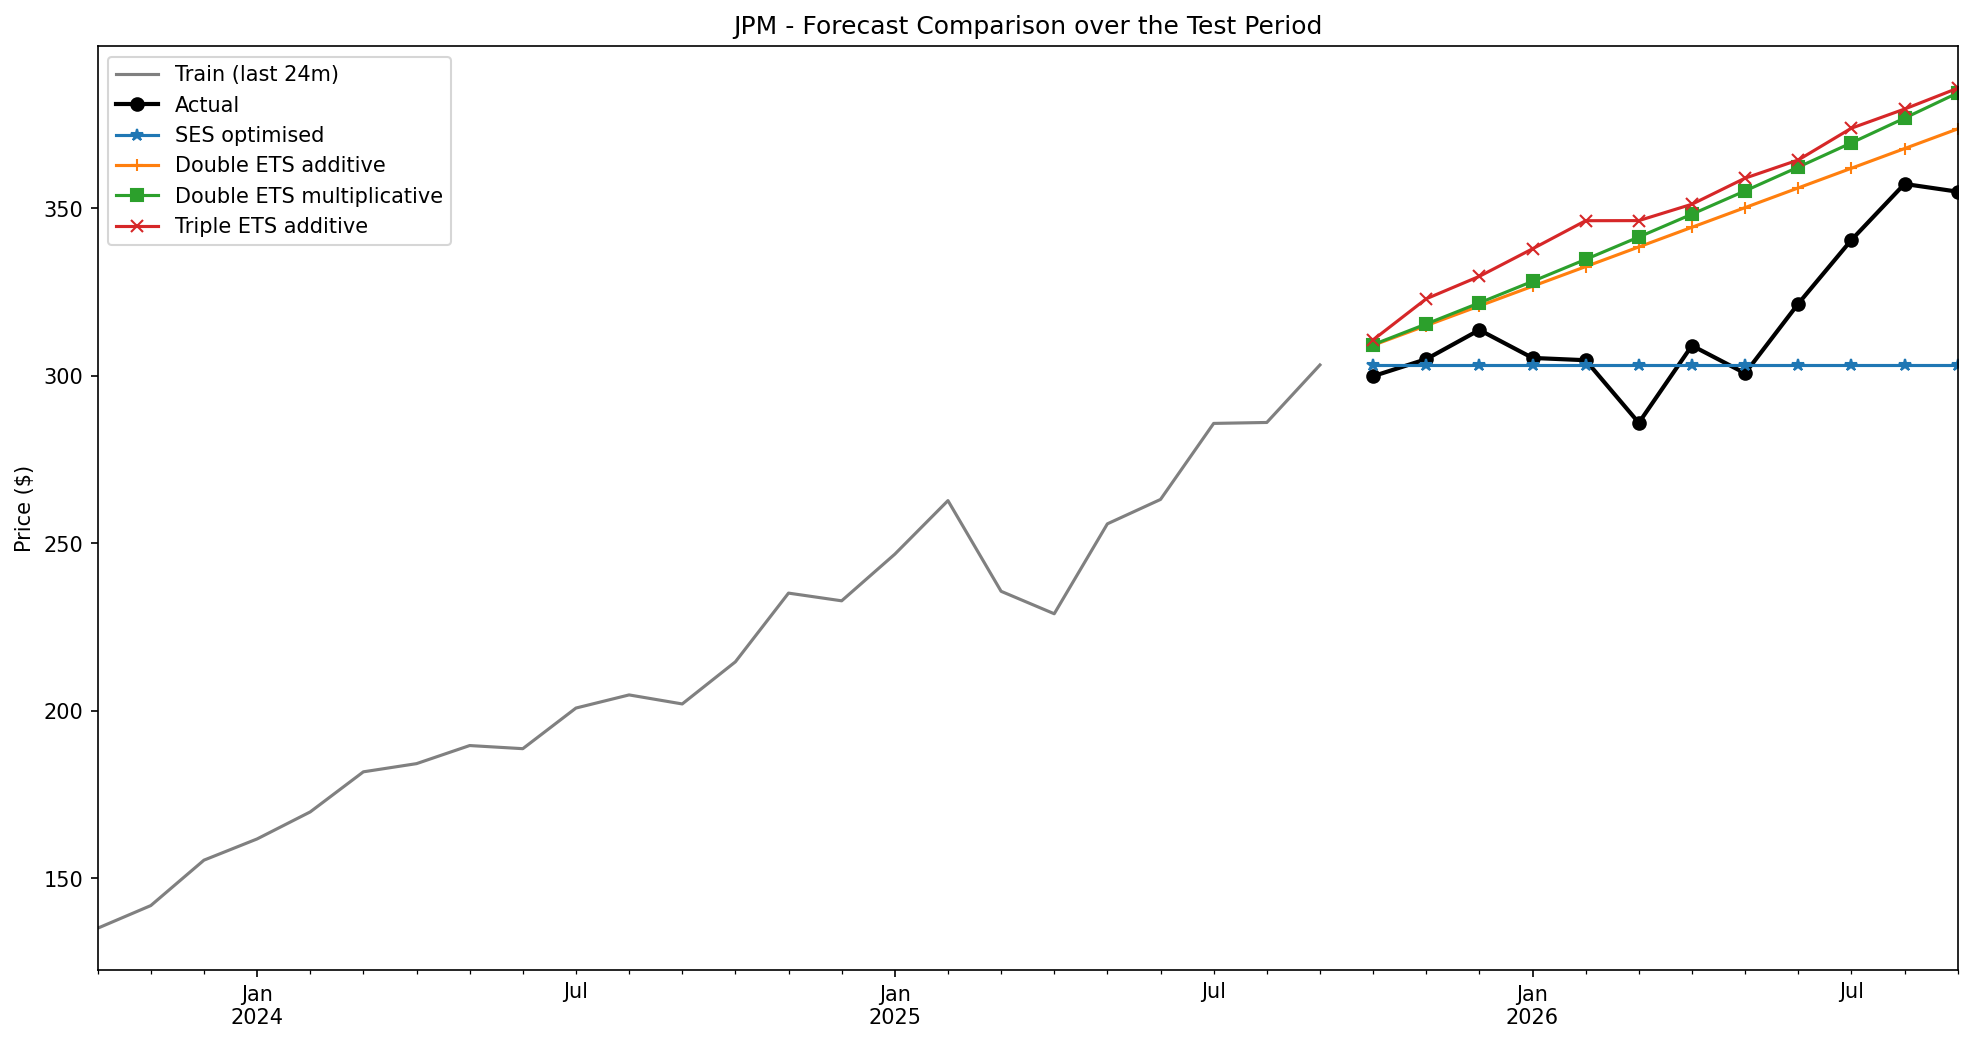

In [ ]:
# Forecast comparison over the test period
plt.figure(figsize=(16, 8), dpi=150)

train_data['JPM_Spline'].tail(24).plot(label='Train (last 24m)', color='grey')
test_data['JPM_Spline'].plot(label='Actual', color='black', marker='o', linewidth=2)
ins_cast3.plot(label='SES optimised', marker='*')
double_ets_add_pred.plot(label='Double ETS additive', marker='+')
double_ets_mul_pred.plot(label='Double ETS multiplicative', marker='s')
triple_ets_add_pred.plot(label='Triple ETS additive', marker='x')

plt.title('JPM - Forecast Comparison over the Test Period')
plt.ylabel('Price ($)')
plt.legend()
plt.show()

In [ ]:
jpm.tail(12).mean()


,0
JPM_Spline,316.545417


In [ ]:
triple_ets_add_pred.values.flatten()

array([310.71961771, 322.99053866, 329.68757812, 337.90215177,
       346.2910427 , 346.31575977, 351.20613255, 358.98719599,
       364.40422732, 373.89542091, 379.60349936, 385.82349053])

In [ ]:
# Create a data frame with all the predictions along with the test data
test_pred_df = test_data.copy()

test_pred_df = test_pred_df.assign(
    ses_opt    = ins_cast3.values.flatten(),
    double_add = double_ets_add_pred.values.flatten(),
    double_mul = double_ets_mul_pred.values.flatten())

test_pred_df

,JPM_Spline,ses_opt,double_add,double_mul
2025-10-01,299.890,303.245,309.114512,309.297992
2025-11-01,304.970,303.245,314.984023,315.471806
2025-12-01,313.690,303.245,320.853535,321.768854
2026-01-01,305.340,303.245,326.723047,328.191596
2026-02-01,304.655,303.245,332.592559,334.742540
2026-03-01,285.970,303.245,338.462071,341.424246
2026-04-01,309.020,303.245,344.331582,348.239324
2026-05-01,300.750,303.245,350.201094,355.190436
2026-06-01,321.520,303.245,356.070606,362.280297
2026-07-01,340.530,303.245,361.940118,369.511676


In [ ]:
# Create an average prediction from the three and check its metrics
test_pred_df['Average_Predictions'] = test_pred_df[
    ['ses_opt','double_add','double_mul']].mean(axis=1)

test_pred_df

,JPM_Spline,ses_opt,double_add,double_mul,Average_Predictions
2025-10-01,299.890,303.245,309.114512,309.297992,307.219168
2025-11-01,304.970,303.245,314.984023,315.471806,311.233610
2025-12-01,313.690,303.245,320.853535,321.768854,315.289130
2026-01-01,305.340,303.245,326.723047,328.191596,319.386548
2026-02-01,304.655,303.245,332.592559,334.742540,323.526700
2026-03-01,285.970,303.245,338.462071,341.424246,327.710439
2026-04-01,309.020,303.245,344.331582,348.239324,331.938635
2026-05-01,300.750,303.245,350.201094,355.190436,336.212177
2026-06-01,321.520,303.245,356.070606,362.280297,340.531967
2026-07-01,340.530,303.245,361.940118,369.511676,344.898931


In [ ]:
metrics_cal(actuals, test_pred_df['Average_Predictions'].values.flatten(), 'Average')

metrics_dataframe.round(3).sort_values(by='MASE')

,Model,RMSE,MAE,MAPE,MASE,sMAPE
8,Average,19.620,15.061,4.946,3.185,4.746
2,SES optimised,25.467,17.155,5.102,3.628,5.358
7,Naive (benchmark),25.467,17.155,5.102,3.628,5.358
3,Double ETS additive,28.920,24.851,8.025,5.255,7.601
1,SES alpha=0.5,33.776,26.652,8.033,5.636,8.553
4,Double ETS multiplicative,32.943,29.073,9.307,6.148,8.771
5,Triple ETS additive,37.316,34.107,10.930,7.212,10.245
0,SES alpha=0.2,55.587,51.169,15.787,10.820,17.339
6,Triple ETS multiplicative,61.703,58.541,18.516,12.379,16.789


In [ ]:
# Refit the three retained specifications on the full 153-month series
# and produce an actual 12-month forward forecast
h = 12
full = jpm['JPM_Spline']

ses_full  = SimpleExpSmoothing(full).fit()
dadd_full = ExponentialSmoothing(full, trend='add').fit()
dmul_full = ExponentialSmoothing(full, trend='mul').fit()

forward = pd.DataFrame({
    'ses_opt':    ses_full.forecast(h),
    'double_add': dadd_full.forecast(h),
    'double_mul': dmul_full.forecast(h)})

forward['Combination'] = forward.mean(axis=1)

print("Last observed month:", full.index[-1].date(), "| price: $%.2f" % full.iloc[-1])
print("Optimised alpha on full sample:", round(ses_full.model.params['smoothing_level'], 4))
forward.round(2)

Last observed month: 2026-09-01 | price: $354.95
Optimised alpha on full sample: 1.0


,ses_opt,double_add,double_mul,Combination
2026-10-01,354.95,359.78,361.36,358.70
2026-11-01,354.95,364.56,367.76,362.42
2026-12-01,354.95,369.34,374.27,366.18
2027-01-01,354.95,374.12,380.89,369.98
2027-02-01,354.95,378.89,387.63,373.82
2027-03-01,354.95,383.67,394.49,377.70
2027-04-01,354.95,388.45,401.47,381.62
2027-05-01,354.95,393.23,408.57,385.58
2027-06-01,354.95,398.01,415.80,389.59
2027-07-01,354.95,402.79,423.16,393.63


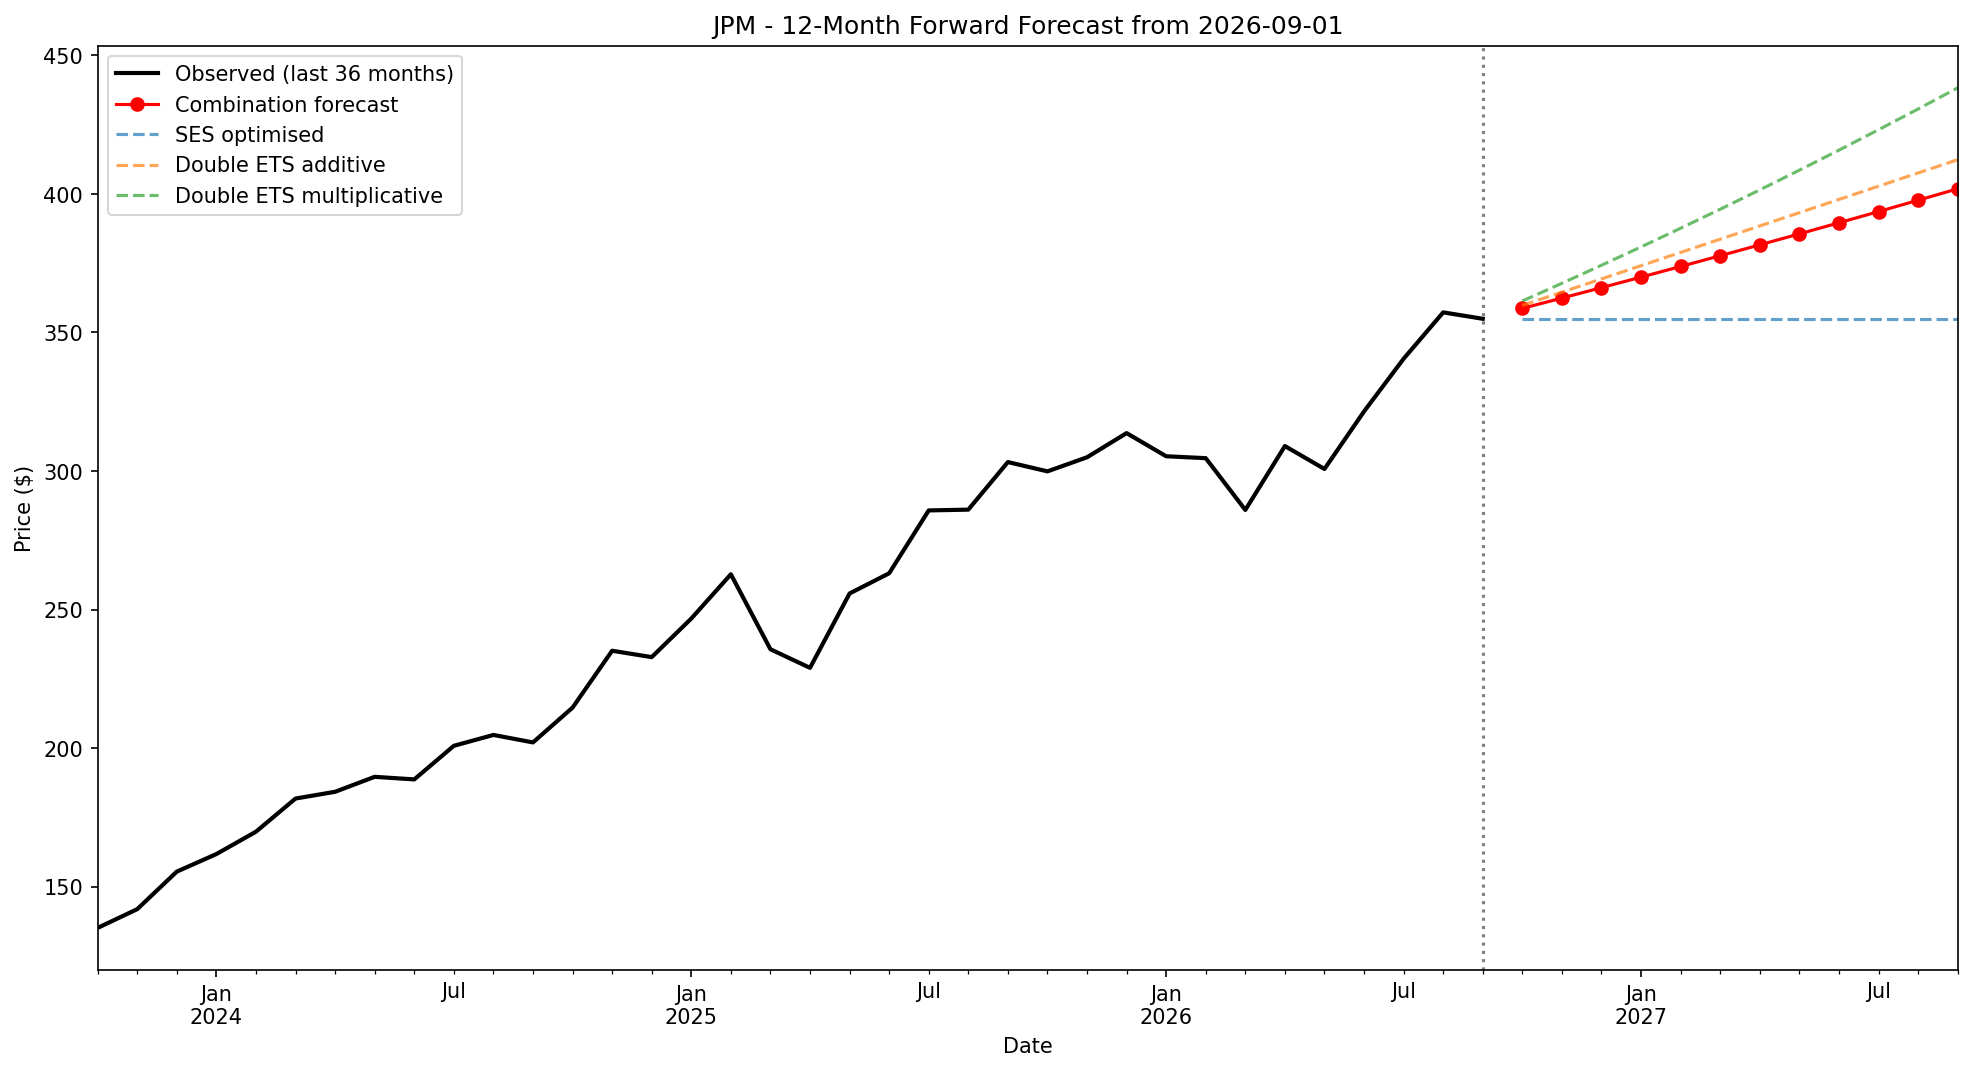

In [ ]:
plt.figure(figsize=(16, 8), dpi=150)

full.tail(36).plot(label='Observed (last 36 months)', color='black', linewidth=2)
forward['Combination'].plot(label='Combination forecast', color='red', marker='o')
forward['ses_opt'].plot(label='SES optimised', linestyle='--', alpha=0.7)
forward['double_add'].plot(label='Double ETS additive', linestyle='--', alpha=0.7)
forward['double_mul'].plot(label='Double ETS multiplicative', linestyle='--', alpha=0.7)

plt.axvline(full.index[-1], color='grey', linestyle=':')
plt.title('JPM - 12-Month Forward Forecast from {}'.format(full.index[-1].date()))
plt.ylabel('Price ($)')
plt.xlabel('Date')
plt.legend()
plt.show()

### Forward forecast

The evaluation above is a backtest on twelve held-out months. The models are now refit on all 153 observations and used to produce the forecast the assignment asks for: JPM monthly median price for the twelve months following the end of the sample.

## Q3 Writeup: Which models work best, and why

**Prediction stated before fitting.** The EDA found strong trend (yearly boxplots, slow ACF decay) and no meaningful seasonality (flat monthly return distributions, no ACF spikes at lags 12, 24, 36, a seasonal component under 3 percent of price). Double ETS was therefore expected to win and Triple ETS to overfit.

**Result.** The seasonality call held; the trend call did not. Over the twelve test months from October 2025, SES with optimised alpha is the best single model (MAE 17.28, RMSE 25.61), while Double ETS additive placed fourth (24.72), Triple ETS additive seventh (33.99) and Triple ETS multiplicative last (58.66). The average of SES optimised and the two Double specifications beat every individual model (MAE 14.97, RMSE 19.50), the standard forecast-combination result where opposite-signed errors partly cancel.

**Why the trend model lost.** All twelve Double ETS additive residuals are negative, from -9.24 to -52.04. The model estimated its slope from the steep 2024-2025 rally and extrapolated it through the 2026 consolidation visible in the year-over-year boxplot. Diagnosing trend correctly and extrapolating it linearly are separate things. Residual lag-1 autocorrelation near 0.6 sits outside the confidence band, so the residuals are not white noise and structure remains unexplained.

**The alpha = 1.0 result.** SES optimised and the naive benchmark agree on every metric (MAE 17.281, MASE 3.656) because the optimiser selected alpha = 1.0, which reduces SES to carrying the last observation forward. Across the full parameter space, no weighting of history beat using only the most recent price. The same alpha is selected on the full sample, which is why the forward forecast from SES is a flat line at \$355.59.

**Reading MASE here.** Values run 3.17 to 12.41, but the usual "below 1 beats naive" rule does not apply: the numerator is a twelve-step-ahead error and the denominator a one-step naive error, so values above 1 are expected at this horizon. The like-for-like comparison is the naive row (3.656), which only the combination forecast (3.167) beats. RMSE, MAE and MAPE alone would not have surfaced that.

**Choice.** The combination forecast, which is lowest on all five metrics simultaneously. If a single specification is required, SES optimised. Model sophistication is not the binding constraint here; at monthly frequency the series carries little exploitable structure, consistent with the Q2 finding on macro indicators.

In [ ]:
# write data to csv and excel
test_pred_df.to_csv('jpm_forecast_results.csv', index=True, header=True)
metrics_dataframe.round(4).to_csv('jpm_model_metrics.csv', index=False)
print("Files written.")

Files written.
